<a href="https://colab.research.google.com/github/Mochdioanugrah/Mini-Project-ML/blob/main/Collab%20Mini%20Project%20ML%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Collab Mini Project Klasifikasi Berita hoax & non-hoax di indonesia**

# **A. Scraping Dataset**

**Instalasi Library Scraping**

In [ ]:
 !pip install requests beautifulsoup4

**Mount Google Drive & Setup Direktori**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')  # ikuti instruksi autentikasi
OUTPUT_DIR = "/content/drive/MyDrive/turnbackhoax_data"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUTPUT_DIR: /content/drive/MyDrive/turnbackhoax_data


**Pemeriksaan robots.txt (Compliance Scraping)**

In [ ]:
import requests
HEADERS = {"User-Agent": "ResearchBot/1.0 (+mailto:you@example.com)"}
r = requests.get("https://turnbackhoax.id/robots.txt", headers=HEADERS, timeout=20)
print("robots.txt status:", r.status_code)
print("--- robots.txt content ---")
print(r.text[:1000])  # tampilkan sebagian agar tidak terlalu panjang



robots.txt status: 200
--- robots.txt content ---
User-agent: *
Disallow: /wp-admin/
Allow: /wp-admin/admin-ajax.php

Sitemap: https://turnbackhoax.id/wp-sitemap.xml



**Scraping dan Ekstraksi Dataset Artikel Hoaks dari TurnBackHoax.id**

In [ ]:
import requests, time, csv, os, re, random
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import pandas as pd

BASE_SITE = "https://turnbackhoax.id"
PAGE_URL = BASE_SITE + "/page/{}/"
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; ResearchBot/1.0; +mailto:you@example.com)"}

# OUTPUT: ganti kalau tidak mount Drive
OUTPUT_DIR = "/content/turnbackhoax_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)
RAW_HTML_DIR = os.path.join(OUTPUT_DIR, "raw_html")
os.makedirs(RAW_HTML_DIR, exist_ok=True)

# Set berapa banyak halaman yang mau di-scan
MAX_PAGES = 30         # ubah sesuai kebutuhan (jangan terlalu besar)
DELAY_MIN = 1.0
DELAY_MAX = 2.0

session = requests.Session()
session.headers.update(HEADERS)

def safe_filename(s):
    s = re.sub(r'[^0-9a-zA-Z\-_.]', '_', s)
    return s[:200]

def get_soup_from_url(url):
    r = session.get(url, timeout=30)
    if r.status_code != 200:
        return None, r.status_code, r.text
    return BeautifulSoup(r.text, "lxml"), r.status_code, r.text

def get_article_links_from_page(page_num):
    url = PAGE_URL.format(page_num)
    soup, status, raw = get_soup_from_url(url)
    if soup is None:
        return None, status
    links = []
    # Heuristik: ambil <article> lalu anchor, fallback ke selectors populer
    for art in soup.find_all("article"):
        a = art.find("a", href=True)
        if a:
            href = urljoin(BASE_SITE, a['href'])
            if href.startswith(BASE_SITE) and href not in links:
                links.append(href)
    if not links:
        # fallback selectors
        for sel in ["h2.entry-title a", "h3.entry-title a", "a[rel='bookmark']"]:
            for a in soup.select(sel):
                href = urljoin(BASE_SITE, a.get("href"))
                if href.startswith(BASE_SITE) and href not in links:
                    links.append(href)
    return links, status

def extract_label_from_soup(soup):
    # Coba cari elemen yang eksplisit (class mengandung verdict/label), lalu heuristik teks.
    candidates = []
    for tag in soup.find_all(True):
        cls = " ".join(tag.get("class") or [])
        if "verdict" in cls.lower() or "label" in cls.lower() or "status" in cls.lower() or "hasil" in cls.lower():
            txt = tag.get_text(" ", strip=True)
            if txt:
                candidates.append(txt)
    # heuristic: cari kata kunci umum
    text_top = ""
    content_top = soup.get_text(" ", strip=True)[:800].lower()
    keywords = ["hoax", "salah", "fakta", "benar", "misleading", "disinformasi", "provokasi"]
    for kw in keywords:
        if kw in content_top:
            # ambil kalimat yang mengandung keyword
            m = re.search(r'([^.!\n]{0,120}\b' + re.escape(kw) + r'\b[^.!\n]{0,120})', content_top)
            if m:
                candidates.append(m.group(1).strip())
    # return shortest candidate (lebih mungkin label ringkas), atau empty string
    if candidates:
        candidates = sorted(set(candidates), key=lambda x: len(x))
        # trim to 250 chars
        return candidates[0][:250]
    return ""

def parse_article(url):
    soup, status, raw = get_soup_from_url(url)
    if soup is None:
        return None, status
    # Simpan raw HTML untuk reproducibility
    parsed = urlparse(url)
    fname = safe_filename(parsed.path.strip("/").replace("/", "_") or parsed.netloc)
    with open(os.path.join(RAW_HTML_DIR, fname + ".html"), "w", encoding="utf-8") as f:
        f.write(raw)

    # Title
    title_tag = soup.find("h1", class_="entry-title") or soup.find("h1")
    title = title_tag.get_text(" ", strip=True) if title_tag else ""

    # Date
    date_tag = soup.find("time", class_="entry-date") or soup.find("time")
    date = date_tag.get("datetime") if date_tag and date_tag.get("datetime") else (date_tag.get_text(" ", strip=True) if date_tag else "")

    # Content
    content_div = soup.find("div", class_=re.compile(r"(post-content|entry-content|td-post-content|post-body)")) or soup.find("article")
    if content_div:
        paragraphs = [p.get_text(" ", strip=True) for p in content_div.find_all("p")]
        content = "\n\n".join([p for p in paragraphs if p])
    else:
        content = soup.get_text(" ", strip=True)[:2000]

    # Label / verdict (heuristic)
    label = extract_label_from_soup(soup)

    return {
        "url": url,
        "title": title,
        "date": date,
        "label": label,
        "content": content
    }, 200

# === RUN SCRAPE ===
all_records = []
seen_urls = set()
for page in range(1, MAX_PAGES + 1):
    print(f"Scanning page {page} ...", end=" ")
    links_status = get_article_links_from_page(page)
    if links_status is None:
        print("failed or 404, stop.")
        break
    links, status = links_status
    if not links:
        print("no links (empty) — stop.")
        break
    print(f"found {len(links)} links")
    for link in links:
        if link in seen_urls:
            continue
        try:
            rec, code = parse_article(link)
            if rec:
                all_records.append(rec)
                seen_urls.add(link)
                print(" -", rec["title"][:80])
            else:
                print(" - failed parse:", link, code)
        except Exception as e:
            print(" - error parsing:", e)
        time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))
    # jeda antar halaman
    time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

# Simpan CSV
df = pd.DataFrame(all_records)
CSV_PATH = os.path.join(OUTPUT_DIR, "turnbackhoax_data.csv")
df.to_csv(CSV_PATH, index=False)
print("Saved", len(df), "records to", CSV_PATH)
# Show preview
df.head(10)

Scanning page 1 ... found 20 links
 - [SALAH] KTP-el Dipasang GPS untuk Pantau Keberadaan Masyarakat
 - [SALAH] Jokowi Setuju RUU Perampasan Aset, Asalkan Tidak Menyasar Mantan Preside
 - [SALAH] Israel Ngambek dan Keluar dari Sidang PBB Ketika Hampir Semua Negara Sep
 - [PENIPUAN] PLN Tawarkan Listrik Gratis Lewat Akun TikTok
 - [SALAH] Ojol Demo Kenaikan Pertalite
 - [SALAH] Panglima NATO akan Buat Kerusuhan di Indonesia
 - [SALAH] Ojol Dilarang Gunakan Pertalite
 - [SALAH] Video Pengiriman 18.000 Personel TNI ke Aceh
 - [SALAH] Pom Bensin Shell Resmi Tutup dan Hengkang dari Indonesia pada 2026
 - [SALAH] Menteri ESDM Bahlil Lahadalia Jadi Tersangka Kasus Korupsi Migas
 - [PENIPUAN] Wapres Gibran Promosikan Program Motor Murah
 - [SALAH] Mobil Ahmad Sahroni Dikepung di Tengah Demo Mahasiswa
 - [SALAH] Gatot Nurmantyo Resmi Jadi Menko Polkam
 - [SALAH] Prabowo Ungkap Gatot Nurmantyo dan Rocky Gerung Masuk Kabinet Merah Puti
 - [SALAH] KPK Panggil Megawati Untuk Diperiksa
 - [PENIPUAN]

,url,title,date,label,content
0,https://turnbackhoax.id/2025/09/30/salah-ktp-e...,[SALAH] KTP-el Dipasang GPS untuk Pantau Keber...,,[salah] ktp-el dipasang gps untuk pantau keber...,Akun Instagram “ 1273alam ” [ arsip ] pada Kam...
1,https://turnbackhoax.id/2025/09/30/salah-jokow...,"[SALAH] Jokowi Setuju RUU Perampasan Aset, Asa...",,"[salah] jokowi setuju ruu perampasan aset, asa...",Pada Selasa (23/9/2025) akun Facebook “Himae H...
2,https://turnbackhoax.id/2025/09/30/salah-israe...,[SALAH] Israel Ngambek dan Keluar dari Sidang ...,,[salah] israel ngambek dan keluar dari sidang ...,Pada Selasa (23/09/2025) akun Tiktok “majuidn”...
3,https://turnbackhoax.id/2025/09/30/penipuan-pl...,[PENIPUAN] PLN Tawarkan Listrik Gratis Lewat A...,,tim pemeriksa fakta mafindo (turnbackhoax) men...,Tim Pemeriksa Fakta Mafindo (TurnBackHoax) men...
4,https://turnbackhoax.id/2025/09/30/salah-ojol-...,[SALAH] Ojol Demo Kenaikan Pertalite,,[salah] ojol demo kenaikan pertalite – turnbac...,Beredar video [arsip] dari akun tiktok “kampun...
5,https://turnbackhoax.id/2025/09/30/salah-pangl...,[SALAH] Panglima NATO akan Buat Kerusuhan di I...,,[salah] panglima nato akan buat kerusuhan di i...,Akun TikTok “pasukankhususalmadi7” pada Senin ...
6,https://turnbackhoax.id/2025/09/30/salah-ojol-...,[SALAH] Ojol Dilarang Gunakan Pertalite,,[salah] ojol dilarang gunakan pertalite – turn...,Pada Sabtu (20/9/2025) akun TikTok “Mr.J-Skull...
7,https://turnbackhoax.id/2025/09/30/salah-video...,[SALAH] Video Pengiriman 18.000 Personel TNI k...,,[salah] video pengiriman 18,Akun Facebook “Muchtadil Hebat Anwar” pada Sab...
8,https://turnbackhoax.id/2025/09/30/salah-pom-b...,[SALAH] Pom Bensin Shell Resmi Tutup dan Hengk...,,[salah] pom bensin shell resmi tutup dan hengk...,Beredar unggahan [arsip] dari akun Facebook “K...
9,https://turnbackhoax.id/2025/09/29/salah-mente...,[SALAH] Menteri ESDM Bahlil Lahadalia Jadi Ter...,,[salah] menteri esdm bahlil lahadalia jadi ter...,Akun Facebook “Bima Silhoute” pada Jumat (26 /...


**Mengecek File Output dan Mengunduh Dataset Hasil Scraping**

In [ ]:
# cek file di /content
import os
print("files in output:", os.listdir("/content/turnbackhoax_data")[:30])
# download
from google.colab import files
files.download("/content/turnbackhoax_data/turnbackhoax_data.csv")


files in output: ['raw_html', 'turnbackhoax_data.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Memuat Dataset Detik & TurnBackHoax serta Mengecek Struktur Awal**

In [ ]:
import pandas as pd

# Membaca kedua file
detik = pd.read_csv("detik_non_hoax_full Scraping.csv")
turnback = pd.read_csv("turnbackhoax_data (2).csv")

# Menampilkan struktur dasar
print("Detik:", detik.shape)
print("TurnBackHoax:", turnback.shape)


Detik: (3893, 3)
TurnBackHoax: (2900, 5)


# **B. Load & Pra-Pemrosesan Data**

In [ ]:
import pandas as pd
import re

# =========================================
# 1. Membaca dataset
# =========================================
turnbackhoax_path = "turnbackhoax_data (2).csv"
detik_path = "detik_non_hoax_full Scraping.csv"

df_turnbackhoax = pd.read_csv(turnbackhoax_path, encoding="utf-8")
df_detik = pd.read_csv(detik_path, encoding="utf-8")

print("Data Turnbackhoax:", df_turnbackhoax.shape)
print("Data Detik Non-hoax:", df_detik.shape)

# =========================================
# 2. Seleksi hanya berita hoaks
# =========================================
mask_hoax = df_turnbackhoax["title"].str.contains(
    "HOAKS|SALAH|DISINFORMASI|MISLEADING|FALSE|FABRICATED|PENIPUAN",
    case=False, na=False
)
df_turnbackhoax = df_turnbackhoax[mask_hoax]

print("Data Turnbackhoax setelah seleksi hoaks:", df_turnbackhoax.shape)

# =========================================
# 3. Bersihkan judul (untuk konsistensi, meski nanti tidak dipakai)
# =========================================
def clean_title(title):
    title = re.sub(r'\[(HOAKS|SALAH|DISINFORMASI|MISLEADING|FALSE|FABRICATED|PENIPUAN)\]', '', title, flags=re.IGNORECASE)
    title = re.sub(r'\s+', ' ', title).strip()
    return title

df_turnbackhoax["title"] = df_turnbackhoax["title"].apply(clean_title)

# =========================================
# 4. Pilih hanya kolom ISI berita (discard judul)
# =========================================
df_turnbackhoax = df_turnbackhoax[["content"]].rename(columns={"content": "isi"})
df_detik = df_detik[["isi_berita"]].rename(columns={"isi_berita": "isi"})

# =========================================
# 5. Tambah label
# =========================================
df_turnbackhoax["label"] = "hoaks"
df_detik["label"] = "non-hoaks"

# =========================================
# 6. Gabungkan dataset
# =========================================
df_combined = pd.concat([df_turnbackhoax, df_detik], ignore_index=True)

# =========================================
# 7. Hapus duplikat & missing
# =========================================
df_combined.drop_duplicates(subset=["isi"], inplace=True)
df_combined.dropna(subset=["isi"], inplace=True)

# =========================================
# 8. Cek hasil
# =========================================
print("\nJumlah total data:", len(df_combined))
print("\nDistribusi label:")
print(df_combined["label"].value_counts())

print("\nContoh data:")
print(df_combined.sample(5))

# =========================================
# 9. Simpan final dataset
# =========================================
output_path = "dataset_hoax_vs_nonhoax_only_isi.csv"
df_combined.to_csv(output_path, index=False, encoding="utf-8")
print(f"\n✅ Dataset final disimpan ke: {output_path}")


Data Turnbackhoax: (2900, 5)
Data Detik Non-hoax: (3893, 3)
Data Turnbackhoax setelah seleksi hoaks: (2870, 5)

Jumlah total data: 6760

Distribusi label:
label
non-hoaks    3891
hoaks        2869
Name: count, dtype: int64

Contoh data:
                                                    isi      label
6384  Tiket MotoGP Mandalika di Lombok Timur, Nusa T...  non-hoaks
1911  Hasil periksa fakta Moch. MarcellodiansyahFakt...      hoaks
2031  Hasil Periksa Fakta Dyah FegriyaniVideo terseb...      hoaks
1998  Hasil periksa fakta Rahmah.Kemendikbud memasti...      hoaks
409   Hasil periksa fakta Yudho ArdiInformasi yang m...      hoaks

✅ Dataset final disimpan ke: dataset_hoax_vs_nonhoax_only_isi.csv


# **C. PreProcessing data**

**0. Load Dataset**

In [ ]:
import pandas as pd

# Membaca dataset gabungan
df = pd.read_csv("dataset_hoax_vs_nonhoax_only_isi.csv")

# Menampilkan 5 data teratas
print("Contoh data sebelum preprocessing:")
print(df.head())


**1. Case Folding pada Kolom Isi Berita (Normalisasi Huruf Kecil)**

In [ ]:
import pandas as pd

# 1. Load dataset gabungan
df = pd.read_csv("dataset_hoax_vs_nonhoax_only_isi.csv")

# 2. Case Folding hanya pada kolom ISI
df["isi_casefold"] = df["isi"].astype(str).str.lower()

# 3. Tampilkan contoh hasil
print("Sebelum Case Folding:\n", df["isi"].iloc[0])
print("\nSesudah Case Folding:\n", df["isi_casefold"].iloc[0])


**2. Text Cleaning (Noise Removal)**

In [ ]:
import re

def clean_text(text):
    # hapus tag label hoax di awal kalimat
    text = re.sub(r"\[(hoax|salah|disinformasi|misleading|false|fabricated|penipuan)\]", "", text, flags=re.IGNORECASE)

    # hapus URL
    text = re.sub(r"http\S+|www\S+", "", text)

    # hapus angka, simbol, tanda baca
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # hapus spasi berlebih
    text = re.sub(r"\s+", " ", text).strip()

    return text

# proses hanya kolom isi
df["isi_bersih"] = df["isi_casefold"].apply(clean_text)

print("Sebelum Cleaning:\n", df["isi_casefold"].iloc[0])
print("\nSesudah Cleaning:\n", df["isi_bersih"].iloc[0])


**3. Tokenisasi Teks: Pemecahan Kalimat menjadi Token Kata (NLTK Word Tokenizer)**

In [ ]:
pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.4 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Download tokenizer NLTK (wajib dua ini untuk versi terbaru)
nltk.download('punkt')
nltk.download('punkt_tab')

# Tokenisasi hanya pada kolom isi
df["token_isi"] = df["isi_bersih"].apply(word_tokenize)

# Contoh output
print("Sebelum Tokenisasi (isi):")
print(df["isi_bersih"].iloc[0])

print("\nSesudah Tokenisasi (isi):")
print(df["token_isi"].iloc[0])


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Sebelum Tokenisasi (isi):
faktanya belum ada dukungan resmi anies untuk pasangan manapun di pilkada jakarta unggahan berisi informasi anies baswedan mendukung calon gubernur dan wakil gubernur nomor urut pramono rano merupakan konten yang menyesatkan misleading content akun instagram lintang son o pada sabtu mengunggahvideo arsip yang memperlihatkan anies mengacungkan jari unggahan disertai takarir anies baswedan mendukung calon gubernur dan wakil gubernur nomor urut mas pram bang doelper rabu konten dilihat hampir kali dan disukai akun pemeriksaan faktadisadur dari artikel periksa fakta tirto id tim pemeriksa fakta tirto melakukan penelusuran dengan membuka media sosial anies melalui akun instagramnya aniesbaswedan terdapat foto anies yang sedang memakai batik dan mengendarai sepeda pada unggahan rabu dalam narasi yang dibagikan anies pada saat itu hanya memperingati hari batik nasional dan hari sepeda nasional bersama kelompok bike to work indonesia tirto melanjutkan penelusuran deng

**4. Stopword Removal: Menghapus Kata Umum Bahasa Indonesia (NLTK Stopwords)**

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download stopwords if belum ada
nltk.download('stopwords')

# Load stopwords bahasa Indonesia
stop_words = set(stopwords.words('indonesian'))

# Hapus stopword pada kolom isi
df["token_isi_tanpa_stopword"] = df["token_isi"].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

# Tampilkan contoh hasil
print("Sebelum Stopword Removal:", df["token_isi"].iloc[0][:20])
print("Sesudah Stopword Removal:", df["token_isi_tanpa_stopword"].iloc[0][:20])


Sebelum Stopword Removal: ['faktanya', 'belum', 'ada', 'dukungan', 'resmi', 'anies', 'untuk', 'pasangan', 'manapun', 'di', 'pilkada', 'jakarta', 'unggahan', 'berisi', 'informasi', 'anies', 'baswedan', 'mendukung', 'calon', 'gubernur']
Sesudah Stopword Removal: ['faktanya', 'dukungan', 'resmi', 'anies', 'pasangan', 'manapun', 'pilkada', 'jakarta', 'unggahan', 'berisi', 'informasi', 'anies', 'baswedan', 'mendukung', 'calon', 'gubernur', 'wakil', 'gubernur', 'nomor', 'urut']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**5. Stemming Bahasa Indonesia Menggunakan Library Sastrawi**

In [ ]:


  from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Stemming pada kolom isi (hasil token tanpa stopword)
df["stem_isi"] = df["token_isi_tanpa_stopword"].apply(lambda tokens: [stemmer.stem(w) for w in tokens])

# Contoh output
print("Sebelum Stemming (isi):", df["token_isi_tanpa_stopword"].iloc[0][:10])
print("Sesudah Stemming (isi):", df["stem_isi"].iloc[0][:10])


Sebelum Stemming (isi): ['faktanya', 'dukungan', 'resmi', 'anies', 'pasangan', 'manapun', 'pilkada', 'jakarta', 'unggahan', 'berisi']
Sesudah Stemming (isi): ['fakta', 'dukung', 'resmi', 'anies', 'pasang', 'mana', 'pilkada', 'jakarta', 'unggah', 'isi']


**6. Menggabungkan Token Hasil Stemming Menjadi Kalimat Utuh**

In [ ]:
# Gabungkan kembali token menjadi kalimat utuh
df["teks_final"] = df["stem_isi"].apply(lambda x: " ".join(x))

print("Contoh Teks Final:", df["teks_final"].iloc[0])


Contoh Teks Final: fakta dukung resmi anies pasang mana pilkada jakarta unggah isi informasi anies baswedan dukung calon gubernur wakil gubernur nomor urut pramono rano konten sesat misleading content akun instagram lintang son o sabtu mengunggahvideo arsip anies acung jari unggah serta takarir anies baswedan dukung calon gubernur wakil gubernur nomor urut mas pram bang doelper rabu konten kali suka akun periksa faktadisadur artikel periksa fakta tirto id tim periksa fakta tirto telusur buka media sosial anies akun instagramnya aniesbaswedan foto anies pakai batik kendara sepeda unggah rabu narasi bagi anies ingat batik nasional sepeda nasional kelompok bike to work indonesia tirto lanjut telusur kunci dukung anies pilkada jakarta google hasil salah artikel tempo judul jubir anies baswedan nyata dukung pilkada jakarta juru bicara anies sahrin hamid anies dukung resmi satu pasang calon gubernur wakil gubernur pilkada jakarta jumat pihak rakyat lemah perhati mas anies tentu pilih tunggu 

**7. Menyimpan Dataset Hasil Preprocessing ke File CSV**

In [ ]:
df.to_csv("dataset_preprocessed_final.csv", index=False, encoding="utf-8")
print("✅ Dataset hasil preprocessing disimpan ke: dataset_preprocessed_final.csv")


✅ Dataset hasil preprocessing disimpan ke: dataset_preprocessed_final.csv


**8. Encoding Label: Konversi Hoaks (1) dan Non-Hoaks (0)bold text**

In [ ]:
import pandas as pd

# 1️⃣ Load dataset hasil preprocessing (tahap sebelumnya)
df = pd.read_csv("dataset_preprocessed_final.csv")

# 2️⃣ Encoding label (ubah hoaks → 1, non-hoaks → 0)
df["label_num"] = df["label"].map({"non-hoaks": 0, "hoaks": 1})

# 3️⃣ Cek keberhasilan encoding
print("\n✅ Contoh Encoding Label:")
print(df[["label", "label_num"]].head(10))

print("\n📊 Jumlah data per kelas:")
print(df["label_num"].value_counts())

# 4️⃣ Simpan dataset final setelah encoding label
output_path = "dataset_ready_for_feature_extraction.csv"
df.to_csv(output_path, index=False, encoding="utf-8")

print(f"\n💾 Dataset final disimpan sebagai: {output_path}")



✅ Contoh Encoding Label:
   label  label_num
0  hoaks          1
1  hoaks          1
2  hoaks          1
3  hoaks          1
4  hoaks          1
5  hoaks          1
6  hoaks          1
7  hoaks          1
8  hoaks          1
9  hoaks          1

📊 Jumlah data per kelas:
label_num
0    3891
1    2869
Name: count, dtype: int64

💾 Dataset final disimpan sebagai: dataset_ready_for_feature_extraction.csv


**9. Exploratory View: Sampel Kolom teks_final dan label_num**

In [ ]:
import pandas as pd

# Load dataset final yang sudah kamu upload
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")

# Tampilkan 20 baris pertama kolom teks_final dan label_num
df[["teks_final", "label_num"]].head(20)


,teks_final,label_num
0,fakta dukung resmi anies pasang mana pilkada j...,1
1,sumber valid benar presiden prabowo ancam nara...,1
2,nyata menkes budi lockdown great reset narasi ...,1
3,hasil cari google arah pemberitaancnbc indones...,1
4,kpk bukti kuat libat pramono puan korupsi e kt...,1
5,warganet periksa media sosial milik king kevin...,1
6,akun instagram resmi ditjenpajakri djp modus t...,1
7,lembaga kredibel rilis hasil survei tanggal in...,1
8,fakta temu informasi sumber kredibel pks mundu...,1
9,taut unggah edar arah tipu akun facebook dafta...,1


# D. Ekstraksi Fitur Menggunakan TF-IDF Vectorization

In [ ]:
# ==============================
# 📦 1. Import Library
# ==============================
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse

# ==============================
# 📂 2. Load Dataset
# ==============================
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")

# Ambil kolom teks dan label
X_text = df["teks_final"].astype(str)
y = df["label_num"]

# ==============================
# 🔠 3. TF-IDF Vectorization
# ==============================
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,     # ambil 5000 kata paling penting
    sublinear_tf=True,     # normalisasi logaritmik TF
    encoding='utf-8',
)

X_tfidf = tfidf_vectorizer.fit_transform(X_text)

# ==============================
# 📊 4. Info Bentuk Matriks
# ==============================
print("✅ TF-IDF selesai diekstraksi.")
print("📏 Bentuk matriks TF-IDF:", X_tfidf.shape)

# ==============================
# 🔍 5. Contoh Nilai TF-IDF (non-zero)
# ==============================
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(X_tfidf[:5].toarray(), columns=feature_names)

for i in range(5):
    print(f"\n📰 Dokumen {i+1}:")
    nonzero = tfidf_df.loc[i][tfidf_df.loc[i] > 0]
    print(nonzero.sort_values(ascending=False).head(10))  # tampilkan 10 kata terpenting per dokumen

# ==============================
# 💾 6. Simpan hasil ekstraksi TF-IDF
# ==============================
scipy.sparse.save_npz("tfidf_features.npz", X_tfidf)

print("\n💾 Hasil ekstraksi TF-IDF berhasil disimpan!")
print("📂 File fitur: tfidf_features.npz")
print("📏 Bentuk fitur:", X_tfidf.shape)


✅ TF-IDF selesai diekstraksi.
📏 Bentuk matriks TF-IDF: (6760, 5000)

📰 Dokumen 1:
anies       0.305029
pilkada     0.264565
gubernur    0.243599
tirto       0.221707
rano        0.218156
baswedan    0.213974
calon       0.201270
urut        0.191479
batik       0.185898
mas         0.164271
Name: 0, dtype: float64

📰 Dokumen 2:
aparatur      0.322623
prabowo       0.246483
ancam         0.243710
rakyat        0.239616
fabricated    0.220051
urus          0.210558
pimpin        0.208759
presiden      0.187179
valid         0.184254
negara        0.152427
Name: 1, dtype: float64

📰 Dokumen 3:
menkes        0.313770
pandemic      0.271661
budi          0.254752
pandemi       0.246330
order         0.230614
new           0.175992
agenda        0.171384
gagas         0.158006
world         0.155813
misleading    0.136996
Name: 2, dtype: float64

📰 Dokumen 4:
militer       0.308229
wajib         0.245363
putri         0.213269
prabowo       0.211409
putra         0.204693
rakyat        0.197

**Contoh Representasi TF-IDF (10 Fitur Teratas)**

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=10)  # ambil 10 kata teratas agar tabel tidak terlalu besar
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

# 4️⃣ Buat DataFrame hasil ekstraksi
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
).round(3)

# 5️⃣ Ambil hanya baris yang punya nilai TF-IDF ≠ 0.0
tfidf_nonzero = tfidf_df[(tfidf_df != 0).any(axis=1)]

# 6️⃣ Tampilkan hanya beberapa baris agar tabel ringkas
print("📊 Contoh representasi hasil ekstraksi TF-IDF (hanya bobot ≠ 0.0):")
print(tfidf_nonzero.head(10))


📊 Contoh representasi hasil ekstraksi TF-IDF (hanya bobot ≠ 0.0):
    akun  content  fakta  hasil  indonesia  konten  periksa   temu  unggah  \
0  0.481    0.228  0.394  0.113      0.143   0.405    0.383  0.000   0.467   
1  0.192    0.273  0.158  0.135      0.000   0.486    0.153  0.167   0.747   
2  0.429    0.305  0.352  0.000      0.191   0.543    0.171  0.187   0.417   
3  0.362    0.257  0.148  0.510      0.323   0.305    0.144  0.158   0.527   
4  0.393    0.279  0.322  0.138      0.351   0.497    0.313  0.171   0.382   
5  0.900    0.116  0.134  0.000      0.000   0.207    0.261  0.071   0.159   
6  0.332    0.472  0.272  0.000      0.000   0.560    0.529  0.000   0.000   
7  0.553    0.157  0.091  0.545      0.099   0.186    0.176  0.000   0.537   
8  0.411    0.292  0.337  0.289      0.183   0.346    0.327  0.358   0.399   
9  0.639    0.227  0.131  0.000      0.000   0.269    0.255  0.000   0.621   

   video  
0  0.000  
1  0.000  
2  0.174  
3  0.000  
4  0.000  
5  0.133 

# E. Ekstraksi Fitur Word2Vec: Pelatihan Model & Representasi Dokumen

In [ ]:
pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.3 MB/s eta 0:00:00


In [ ]:
# ================================================================
# 📦 1. Import Library
# ================================================================
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
import joblib

# ================================================================
# 📂 2. Load Dataset
# ================================================================
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")

# Ambil kolom teks saja
X_text = df["teks_final"].astype(str)

# ================================================================
# 🧠 3. Word2Vec Feature Extraction
# ================================================================
print("🔹 Ekstraksi fitur Word2Vec dimulai...")

# 3.1 Tokenisasi sederhana (ubah teks jadi list kata)
sentences = [text.split() for text in X_text]

# 3.2 Latih model Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,   # dimensi vektor tiap kata
    window=5,          # konteks kata (5 kata di sekitar)
    min_count=2,       # hanya kata muncul ≥2 kali yang dilatih
    workers=4,
    sg=1               # gunakan skip-gram (lebih baik untuk data kecil)
)

# Simpan model Word2Vec agar bisa digunakan lagi nanti
w2v_model.save("word2vec_model.model")

print("✅ Model Word2Vec selesai dilatih.")
print("📏 Jumlah kata dalam kosakata model:", len(w2v_model.wv.index_to_key))

# ================================================================
# 🧩 4. Representasi Dokumen
# ================================================================
# Fungsi untuk menghitung rata-rata vektor dari kata-kata dalam 1 dokumen
def document_vector(doc):
    words = [word for word in doc if word in w2v_model.wv.index_to_key]
    if len(words) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(w2v_model.wv[words], axis=0)

# 4.1 Ubah semua dokumen menjadi vektor
X_w2v = np.array([document_vector(doc) for doc in sentences])

print("✅ Dokumen berhasil diubah menjadi vektor.")
print("📏 Bentuk matriks Word2Vec:", X_w2v.shape)

# ================================================================
# 💾 5. Simpan Hasil Ekstraksi
# ================================================================
joblib.dump(X_w2v, "word2vec_features.joblib")

print("\n💾 Fitur Word2Vec disimpan sebagai 'word2vec_features.joblib'")
print("Model Word2Vec disimpan sebagai 'word2vec_model.model'")


🔹 Ekstraksi fitur Word2Vec dimulai...
✅ Model Word2Vec selesai dilatih.
📏 Jumlah kata dalam kosakata model: 23891
✅ Dokumen berhasil diubah menjadi vektor.
📏 Bentuk matriks Word2Vec: (6760, 100)

💾 Fitur Word2Vec disimpan sebagai 'word2vec_features.joblib'
Model Word2Vec disimpan sebagai 'word2vec_model.model'


# Train–Test Split untuk Fitur TF-IDF

In [ ]:
# ==============================
# 📦 1. Import Library
# ==============================
from sklearn.model_selection import train_test_split
import joblib
import scipy.sparse
import pandas as pd


In [ ]:
# ==============================
# 📂 2. Load Data
# ==============================
# Baca dataset untuk mengambil label
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
y = df["label_num"]

# 🔹 Load TF-IDF
X_tfidf = scipy.sparse.load_npz("tfidf_features.npz")

# 🔹 Load Word2Vec
X_w2v = joblib.load("word2vec_features.joblib")


In [ ]:
# ==============================
# 📂 2. Load Data
# ==============================
# Baca dataset untuk mengambil label
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
y = df["label_num"]

# 🔹 Load TF-IDF
X_tfidf = scipy.sparse.load_npz("tfidf_features.npz")

# 🔹 Load Word2Vec
X_w2v = joblib.load("word2vec_features.joblib")


# ==============================
# ✂️ 3. Split Dataset (TF-IDF)
# ==============================
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y,
    test_size=0.2,         # 80% train, 20% test
    random_state=42,       # untuk hasil yang konsisten
    stratify=y             # agar proporsi label tetap sama
)

print("✅ TF-IDF berhasil di-split.")
print("📏 Train:", X_train_tfidf.shape, " Test:", X_test_tfidf.shape)
print("🔸 Distribusi label Train:\n", y_train_tfidf.value_counts(normalize=True))
print("🔹 Distribusi label Test:\n", y_test_tfidf.value_counts(normalize=True))


✅ TF-IDF berhasil di-split.
📏 Train: (5408, 5000)  Test: (1352, 5000)
🔸 Distribusi label Train:
 label_num
0    0.575629
1    0.424371
Name: proportion, dtype: float64
🔹 Distribusi label Test:
 label_num
0    0.575444
1    0.424556
Name: proportion, dtype: float64


# Train–Test Split untuk Fitur Word2Vec

In [ ]:
# ==============================
# ✂️ 4. Split Dataset (Word2Vec)
# ==============================
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n✅ Word2Vec berhasil di-split.")
print("📏 Train:", X_train_w2v.shape, " Test:", X_test_w2v.shape)
print("🔸 Distribusi label Train:\n", y_train_w2v.value_counts(normalize=True))
print("🔹 Distribusi label Test:\n", y_test_w2v.value_counts(normalize=True))



✅ Word2Vec berhasil di-split.
📏 Train: (5408, 100)  Test: (1352, 100)
🔸 Distribusi label Train:
 label_num
0    0.575629
1    0.424371
Name: proportion, dtype: float64
🔹 Distribusi label Test:
 label_num
0    0.575444
1    0.424556
Name: proportion, dtype: float64


**Menyimpan hasil split Dataset**

In [ ]:
# ==============================
# 💾 5. Simpan Hasil Split
# ==============================
joblib.dump((X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf), "split_tfidf.joblib")
joblib.dump((X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v), "split_word2vec.joblib")

print("\n💾 Split dataset berhasil disimpan!")



💾 Split dataset berhasil disimpan!


# **F. Balancing Data Menggunakan SMOTE**

In [ ]:
# ==============================
# 📦 1. Import Library
# ==============================
from imblearn.over_sampling import SMOTE
import joblib
import pandas as pd

# ==============================
# 📂 2. Load Hasil Split Dataset
# ==============================
# Ambil hasil split dari tahap sebelumnya (TF-IDF dan Word2Vec)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = joblib.load("split_tfidf.joblib")
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = joblib.load("split_word2vec.joblib")

# ==============================
# ⚖️ 3. Balancing Data (SMOTE)
# ==============================
print("🔹 Proses SMOTE dimulai...")

# Inisialisasi SMOTE
smote = SMOTE(random_state=42, sampling_strategy='auto')

# --- TF-IDF ---
X_train_tfidf_bal, y_train_tfidf_bal = smote.fit_resample(X_train_tfidf, y_train_tfidf)
print("\n✅ SMOTE (TF-IDF) selesai.")
print("📏 Sebelum SMOTE:", X_train_tfidf.shape, " | Sesudah SMOTE:", X_train_tfidf_bal.shape)
print("📊 Distribusi label sesudah SMOTE (TF-IDF):")
print(pd.Series(y_train_tfidf_bal).value_counts())

# --- Word2Vec ---
X_train_w2v_bal, y_train_w2v_bal = smote.fit_resample(X_train_w2v, y_train_w2v)
print("\n✅ SMOTE (Word2Vec) selesai.")
print("📏 Sebelum SMOTE:", X_train_w2v.shape, " | Sesudah SMOTE:", X_train_w2v_bal.shape)
print("📊 Distribusi label sesudah SMOTE (Word2Vec):")
print(pd.Series(y_train_w2v_bal).value_counts())

# ==============================
# 💾 4. Simpan Hasil SMOTE
# ==============================
joblib.dump((X_train_tfidf_bal, y_train_tfidf_bal, X_test_tfidf, y_test_tfidf), "balanced_tfidf.joblib")
joblib.dump((X_train_w2v_bal, y_train_w2v_bal, X_test_w2v, y_test_w2v), "balanced_word2vec.joblib")

print("\n💾 Hasil balancing (SMOTE) berhasil disimpan!")
print("📂 File: balanced_tfidf.joblib & balanced_word2vec.joblib")


🔹 Proses SMOTE dimulai...

✅ SMOTE (TF-IDF) selesai.
📏 Sebelum SMOTE: (5408, 5000)  | Sesudah SMOTE: (6226, 5000)
📊 Distribusi label sesudah SMOTE (TF-IDF):
label_num
0    3113
1    3113
Name: count, dtype: int64

✅ SMOTE (Word2Vec) selesai.
📏 Sebelum SMOTE: (5408, 100)  | Sesudah SMOTE: (6226, 100)
📊 Distribusi label sesudah SMOTE (Word2Vec):
label_num
0    3113
1    3113
Name: count, dtype: int64

💾 Hasil balancing (SMOTE) berhasil disimpan!
📂 File: balanced_tfidf.joblib & balanced_word2vec.joblib


# G. Seleksi Fitur (Chi-Square, ANOVA F-test, Mutual Information)

In [ ]:
  # ================================================================
  # 📦 1. Import Library
  # ================================================================
  import warnings
  warnings.filterwarnings("ignore", category=UserWarning)
  warnings.filterwarnings("ignore", category=RuntimeWarning)

  import joblib
  import numpy as np
  import pandas as pd
  from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif

  # ================================================================
  # 📂 2. Load Data Hasil SMOTE (TF-IDF)
  # ================================================================
  data_tfidf = joblib.load("balanced_tfidf.joblib")

  # Unpack sesuai urutan (train_X, train_y, test_X, test_y)
  X_train_tfidf, y_train_tfidf, X_test_tfidf, y_test_tfidf = data_tfidf

  print("✅ Data TF-IDF hasil SMOTE berhasil dimuat.")
  print("📏 Bentuk fitur (train):", X_train_tfidf.shape)
  print("📊 Distribusi label:")
  print(y_train_tfidf.value_counts())

  # Pastikan label dalam bentuk array numerik
  y_train_tfidf = np.array(y_train_tfidf, dtype=int)

  # ================================================================
  # ⚙️ 3. Seleksi Fitur (3 Metode)
  # ================================================================
  K = 2000  # jumlah fitur terpilih

  # -----------------------------
  # 3.1 Chi-Square
  # -----------------------------
  chi2_selector = SelectKBest(score_func=chi2, k=K)
  X_train_chi2 = chi2_selector.fit_transform(X_train_tfidf, y_train_tfidf)
  X_test_chi2 = chi2_selector.transform(X_test_tfidf)

  chi2_scores = chi2_selector.scores_
  chi2_mean = np.nanmean(chi2_scores)
  chi2_top_idx = np.argsort(chi2_scores)[-10:][::-1]

  print("\n🔹 Chi-Square")
  print(f"   ➜ {X_train_tfidf.shape} → {X_train_chi2.shape}")
  print(f"   📈 Rata-rata skor fitur: {chi2_mean:.4f}")
  print(f"   🏆 Top 10 fitur terbaik (index): {chi2_top_idx.tolist()}")

  # -----------------------------
  # 3.2 ANOVA F-test
  # -----------------------------
  anova_selector = SelectKBest(score_func=f_classif, k=K)
  X_train_anova = anova_selector.fit_transform(X_train_tfidf, y_train_tfidf)
  X_test_anova = anova_selector.transform(X_test_tfidf)

  anova_scores = anova_selector.scores_
  anova_mean = np.nanmean(anova_scores)
  anova_top_idx = np.argsort(anova_scores)[-10:][::-1]

  print("\n🔹 ANOVA F-test")
  print(f"   ➜ {X_train_tfidf.shape} → {X_train_anova.shape}")
  print(f"   📈 Rata-rata skor fitur: {anova_mean:.4f}")
  print(f"   🏆 Top 10 fitur terbaik (index): {anova_top_idx.tolist()}")

  # -----------------------------
  # 3.3 Mutual Information
  # -----------------------------
  mi_selector = SelectKBest(score_func=mutual_info_classif, k=K)
  X_train_mi = mi_selector.fit_transform(X_train_tfidf, y_train_tfidf)
  X_test_mi = mi_selector.transform(X_test_tfidf)

  mi_scores = mi_selector.scores_
  mi_mean = np.nanmean(mi_scores)
  mi_top_idx = np.argsort(mi_scores)[-10:][::-1]

  print("\n🔹 Mutual Information")
  print(f"   ➜ {X_train_tfidf.shape} → {X_train_mi.shape}")
  print(f"   📈 Rata-rata skor fitur: {mi_mean:.4f}")
  print(f"   🏆 Top 10 fitur terbaik (index): {mi_top_idx.tolist()}")

  # ================================================================
  # 💾 4. Simpan Hasil Seleksi Fitur
  # ================================================================
  joblib.dump((X_train_chi2, X_test_chi2, y_train_tfidf, y_test_tfidf), "selected_features_chi2.joblib")
  joblib.dump((X_train_anova, X_test_anova, y_train_tfidf, y_test_tfidf), "selected_features_anova.joblib")
  joblib.dump((X_train_mi, X_test_mi, y_train_tfidf, y_test_tfidf), "selected_features_mi.joblib")

  print("\n💾 Hasil seleksi fitur berhasil disimpan!")
  print("📂 File:")
  print(" - selected_features_chi2.joblib")
  print(" - selected_features_anova.joblib")
  print(" - selected_features_mi.joblib")

  # ================================================================
  # 🧾 5. Ringkasan Perbandingan
  # ================================================================
  comparison = pd.DataFrame({
      "Metode": ["Chi-Square", "ANOVA F-test", "Mutual Information"],
      "Fitur Awal": [X_train_tfidf.shape[1]] * 3,
      "Fitur Terpilih": [K] * 3,
      "Rata-rata Skor": [chi2_mean, anova_mean, mi_mean]
  })

  print("\n📊 Perbandingan Hasil Seleksi Fitur:")
  print(comparison.to_string(index=False))


✅ Data TF-IDF hasil SMOTE berhasil dimuat.
📏 Bentuk fitur (train): (6226, 5000)
📊 Distribusi label:
label_num
0    3113
1    3113
Name: count, dtype: int64

🔹 Chi-Square
   ➜ (6226, 5000) → (6226, 2000)
   📈 Rata-rata skor fitur: 3.4665
   🏆 Top 10 fitur terbaik (index): [3580, 3725, 3830, 1527, 2259, 1199, 4766, 106, 3666, 2024]

🔹 ANOVA F-test
   ➜ (6226, 5000) → (6226, 2000)
   📈 Rata-rata skor fitur: 62.9728
   🏆 Top 10 fitur terbaik (index): [3580, 1527, 3725, 3830, 3666, 1199, 2259, 1850, 2024, 808]

🔹 Mutual Information
   ➜ (6226, 5000) → (6226, 2000)
   📈 Rata-rata skor fitur: 0.0125
   🏆 Top 10 fitur terbaik (index): [1199, 3666, 2024, 3308, 1850, 2259, 4291, 1517, 806, 4583]

💾 Hasil seleksi fitur berhasil disimpan!
📂 File:
 - selected_features_chi2.joblib
 - selected_features_anova.joblib
 - selected_features_mi.joblib

📊 Perbandingan Hasil Seleksi Fitur:
            Metode  Fitur Awal  Fitur Terpilih  Rata-rata Skor
        Chi-Square        5000            2000        3.4

# **H. Pembangunan Model Machine Learning Klasik**

# 1. Bangun Model dengan Representasi Fitur TF-IDF Menggunakan Algoritma :

     - Logistic Regression
     - SVM Linear
     - Random Forest

**Load Dataset Hasil Seleksi Fitur (ANOVA) & Persiapan Data Modeling**

In [ ]:
# ================================================================
# 📦 1. Import Library
# ================================================================
import joblib
import numpy as np

# ================================================================
# 📂 2. Load Hasil Seleksi Fitur (misalnya ANOVA F-test)
# ================================================================
X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load("selected_features_anova.joblib")

print("✅ Data hasil seleksi fitur berhasil dimuat.")
print(f"📏 Bentuk data train: {X_train_sel.shape}")
print(f"📏 Bentuk data test : {X_test_sel.shape}")
print(f"🔸 Jumlah data latih : {len(y_train_sel)}")
print(f"🔹 Jumlah data uji    : {len(y_test_sel)}")

# Pastikan label berupa numpy array integer
y_train_sel = np.array(y_train_sel, dtype=int)
y_test_sel = np.array(y_test_sel, dtype=int)
print("\n🎯 Contoh label:", y_train_sel[:10])


✅ Data hasil seleksi fitur berhasil dimuat.
📏 Bentuk data train: (6226, 2000)
📏 Bentuk data test : (1352, 2000)
🔸 Jumlah data latih : 6226
🔹 Jumlah data uji    : 1352

🎯 Contoh label: [0 1 0 0 0 1 1 0 1 1]


**Pelatihan & Evaluasi Model Logistic Regression dengan Fitur Terpilih**

🚀 Melatih model Logistic Regression...
✅ Model Logistic Regression berhasil dilatih!

🎯 Akurasi: 0.9985

📊 Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352



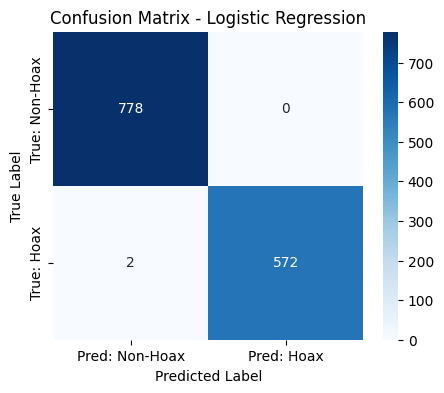

In [ ]:
# ================================================================
# 📦 1. Import Library
# ================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================================================
# 🧠 2. Inisialisasi dan Latih Model
# ================================================================
logreg_model = LogisticRegression(max_iter=1000, solver='lbfgs')

print("🚀 Melatih model Logistic Regression...")
logreg_model.fit(X_train_sel, y_train_sel)
print("✅ Model Logistic Regression berhasil dilatih!")

# ================================================================
# 🔍 3. Evaluasi Model
# ================================================================
y_pred = logreg_model.predict(X_test_sel)

accuracy = accuracy_score(y_test_sel, y_pred)
print(f"\n🎯 Akurasi: {accuracy:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test_sel, y_pred, target_names=["Non-Hoax", "Hoax"]))

# ================================================================
# 📉 4. Confusion Matrix
# ================================================================
cm = confusion_matrix(y_test_sel, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred: Non-Hoax", "Pred: Hoax"], yticklabels=["True: Non-Hoax", "True: Hoax"])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


**Pelatihan & Evaluasi Model Support Vector Machine (LinearSVC) dengan Fitur Terpilih**

🚀 Melatih model Support Vector Machine (LinearSVC)...
✅ Model SVM berhasil dilatih!

🎯 Akurasi SVM: 1.0000

📊 Classification Report (SVM):
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352



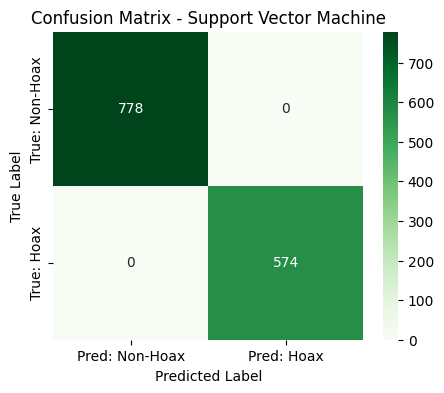

In [ ]:
# ================================================================
# 📦 1. Import Library
# ================================================================
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================================================
# 🧠 2. Inisialisasi dan Latih Model
# ================================================================
svm_model = LinearSVC()

print("🚀 Melatih model Support Vector Machine (LinearSVC)...")
svm_model.fit(X_train_sel, y_train_sel)
print("✅ Model SVM berhasil dilatih!")

# ================================================================
# 🔍 3. Evaluasi Model
# ================================================================
y_pred_svm = svm_model.predict(X_test_sel)

accuracy_svm = accuracy_score(y_test_sel, y_pred_svm)
print(f"\n🎯 Akurasi SVM: {accuracy_svm:.4f}")

print("\n📊 Classification Report (SVM):")
print(classification_report(y_test_sel, y_pred_svm, target_names=["Non-Hoax", "Hoax"]))

# ================================================================
# 📉 4. Confusion Matrix
# ================================================================
cm_svm = confusion_matrix(y_test_sel, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=["Pred: Non-Hoax", "Pred: Hoax"], yticklabels=["True: Non-Hoax", "True: Hoax"])
plt.title("Confusion Matrix - Support Vector Machine")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


**Pelatihan & Evaluasi Model Random Forest dengan Fitur Terpilih**

🚀 Melatih model Random Forest...
✅ Model Random Forest berhasil dilatih!

🎯 Akurasi Random Forest: 1.0000

📊 Classification Report (Random Forest):
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352



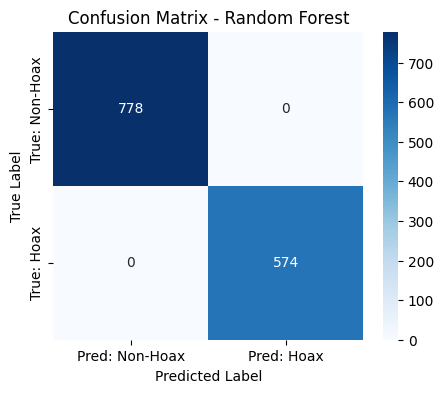

In [ ]:
# ================================================================
# 📦 1. Import Library
# ================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ================================================================
# 🧠 2. Inisialisasi dan Latih Model
# ================================================================
rf_model = RandomForestClassifier(
    n_estimators=200,      # jumlah pohon
    random_state=42,
    n_jobs=-1
)

print("🚀 Melatih model Random Forest...")
rf_model.fit(X_train_sel, y_train_sel)
print("✅ Model Random Forest berhasil dilatih!")

# ================================================================
# 🔍 3. Evaluasi Model
# ================================================================
y_pred_rf = rf_model.predict(X_test_sel)

accuracy_rf = accuracy_score(y_test_sel, y_pred_rf)
print(f"\n🎯 Akurasi Random Forest: {accuracy_rf:.4f}")

print("\n📊 Classification Report (Random Forest):")
print(classification_report(y_test_sel, y_pred_rf, target_names=["Non-Hoax", "Hoax"]))

# ================================================================
# 📉 4. Confusion Matrix
# ================================================================
cm_rf = confusion_matrix(y_test_sel, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred: Non-Hoax", "Pred: Hoax"],
            yticklabels=["True: Non-Hoax", "True: Hoax"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


**Visualisasi Perbandingan Akurasi Model**

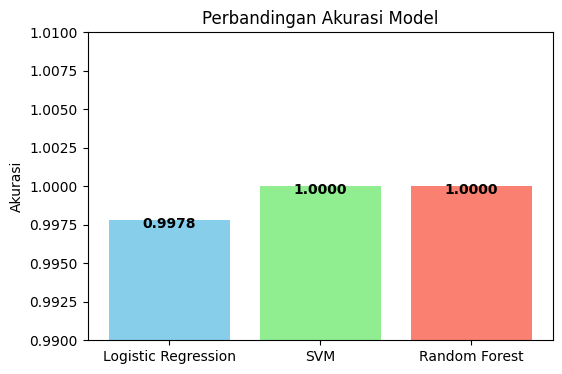

In [ ]:
import matplotlib.pyplot as plt

# Data performa model
models = ["Logistic Regression", "SVM", "Random Forest"]
accuracy = [0.9978, 1.0000, 1.0000]

plt.figure(figsize=(6,4))
plt.bar(models, accuracy, color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Perbandingan Akurasi Model")
plt.ylabel("Akurasi")
plt.ylim(0.99, 1.01)
for i, v in enumerate(accuracy):
    plt.text(i, v - 0.0005, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()


# 2. Bangun Model dengan Representasi Fitur Word2Vec Menggunakan Algoritma :

     - Logistic Regression
     - SVM Linear
     - Random Forest

**Load Dataset Word2Vec Hasil SMOTE & Pemeriksaan Struktur Data**

In [ ]:
import joblib

# ================================================================
# 1️⃣ LOAD DATA HASIL SMOTE (WORD2VEC)
# ================================================================

# Coba load hasil balancing SMOTE untuk Word2Vec
data_w2v = joblib.load("balanced_word2vec.joblib")

# Cek isi dan struktur objek
print("🔍 Mengecek isi file balanced_word2vec.joblib ...")
print(f"Tipe objek : {type(data_w2v)}")
if isinstance(data_w2v, tuple):
    print(f"Jumlah elemen dalam tuple: {len(data_w2v)}")
    for i, item in enumerate(data_w2v):
        if hasattr(item, 'shape'):
            print(f"➡️ Elemen {i}: tipe {type(item)}, bentuk {item.shape}")
        else:
            print(f"➡️ Elemen {i}: tipe {type(item)}")

# Jika sesuai, pisahkan ke variabel
X_train_w2v, y_train_w2v, X_test_w2v, y_test_w2v = data_w2v

print("\n✅ Data Word2Vec hasil SMOTE berhasil dimuat.")
print("📏 Bentuk data train:", X_train_w2v.shape)
print("📏 Bentuk data test :", X_test_w2v.shape)
print("🔸 Jumlah data latih :", len(y_train_w2v))
print("🔹 Jumlah data uji    :", len(y_test_w2v))


🔍 Mengecek isi file balanced_word2vec.joblib ...
Tipe objek : <class 'tuple'>
Jumlah elemen dalam tuple: 4
➡️ Elemen 0: tipe <class 'numpy.ndarray'>, bentuk (6226, 100)
➡️ Elemen 1: tipe <class 'pandas.core.series.Series'>, bentuk (6226,)
➡️ Elemen 2: tipe <class 'numpy.ndarray'>, bentuk (1352, 100)
➡️ Elemen 3: tipe <class 'pandas.core.series.Series'>, bentuk (1352,)

✅ Data Word2Vec hasil SMOTE berhasil dimuat.
📏 Bentuk data train: (6226, 100)
📏 Bentuk data test : (1352, 100)
🔸 Jumlah data latih : 6226
🔹 Jumlah data uji    : 1352


**Pelatihan & Evaluasi Model Logistic Regression (Word2Vec)**

Melatih model Logistic Regression dengan Word2Vec...

✅ Model Logistic Regression (Word2Vec) berhasil dilatih!
🎯 Akurasi: 0.9889

📊 Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       0.99      0.99      0.99       778
        Hoax       0.99      0.99      0.99       574

    accuracy                           0.99      1352
   macro avg       0.99      0.99      0.99      1352
weighted avg       0.99      0.99      0.99      1352

🧩 Confusion Matrix (Logistic Regression - Word2Vec):
 [[771   7]
 [  8 566]]


<Figure size 600x500 with 0 Axes>

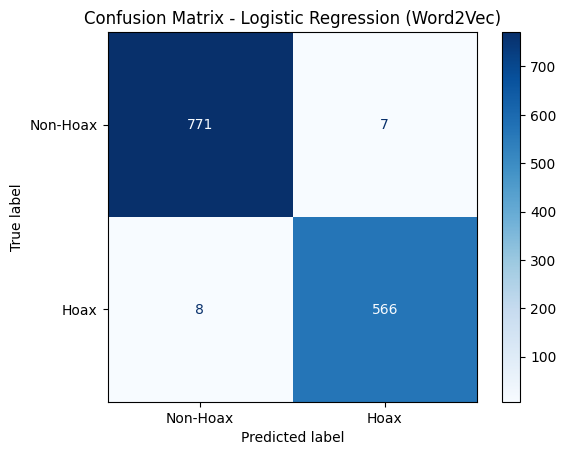

In [ ]:
# ================================================================
# 1️⃣ TRAINING MODEL LOGISTIC REGRESSION (WORD2VEC)
# ================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Inisialisasi model Logistic Regression
logreg_w2v = LogisticRegression(max_iter=1000, random_state=42)

print("Melatih model Logistic Regression dengan Word2Vec...")
logreg_w2v.fit(X_train_w2v, y_train_w2v)

# Prediksi pada data uji
y_pred_logreg_w2v = logreg_w2v.predict(X_test_w2v)

# Evaluasi performa model
acc_logreg_w2v = accuracy_score(y_test_w2v, y_pred_logreg_w2v)
report_logreg_w2v = classification_report(y_test_w2v, y_pred_logreg_w2v, target_names=["Non-Hoax", "Hoax"])

print("\n✅ Model Logistic Regression (Word2Vec) berhasil dilatih!")
print(f"🎯 Akurasi: {acc_logreg_w2v:.4f}")
print("\n📊 Classification Report:")
print(report_logreg_w2v)

# ================================================================
# 🔹 CONFUSION MATRIX UNTUK LOGISTIC REGRESSION (WORD2VEC)
# ================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Hitung confusion matrix
cm_logreg_w2v = confusion_matrix(y_test_w2v, y_pred_logreg_w2v)
print("🧩 Confusion Matrix (Logistic Regression - Word2Vec):\n", cm_logreg_w2v)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logreg_w2v, display_labels=["Non-Hoax", "Hoax"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Logistic Regression (Word2Vec)")
plt.grid(False)
plt.show()


**Pelatihan & Evaluasi Model SVM (LinearSVC) dengan Word2Vec**

Melatih model Support Vector Machine (SVM) dengan Word2Vec...

✅ Model SVM (Word2Vec) berhasil dilatih!
🎯 Akurasi: 0.9978

📊 Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

🧩 Confusion Matrix (SVM - Word2Vec):
 [[776   2]
 [  1 573]]


<Figure size 600x500 with 0 Axes>

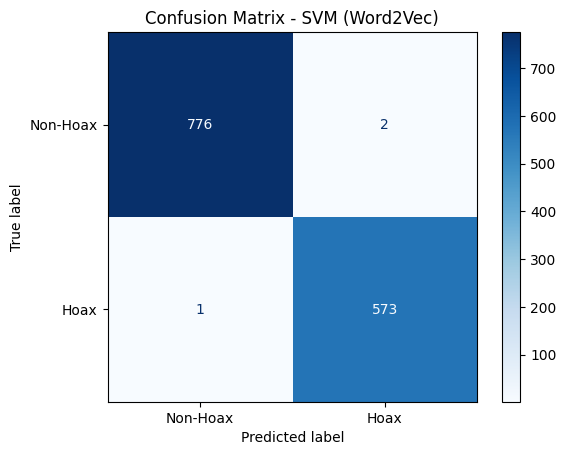

In [ ]:
# ================================================================
# 2️⃣ TRAINING MODEL SUPPORT VECTOR MACHINE (WORD2VEC)
# ================================================================
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Inisialisasi model SVM Linear
svm_w2v = LinearSVC(random_state=42)

print("Melatih model Support Vector Machine (SVM) dengan Word2Vec...")
svm_w2v.fit(X_train_w2v, y_train_w2v)

# Prediksi pada data uji
y_pred_svm_w2v = svm_w2v.predict(X_test_w2v)

# Evaluasi performa model
acc_svm_w2v = accuracy_score(y_test_w2v, y_pred_svm_w2v)
report_svm_w2v = classification_report(y_test_w2v, y_pred_svm_w2v, target_names=["Non-Hoax", "Hoax"])

print("\n✅ Model SVM (Word2Vec) berhasil dilatih!")
print(f"🎯 Akurasi: {acc_svm_w2v:.4f}")
print("\n📊 Classification Report:")
print(report_svm_w2v)

# ================================================================
# 🔹 CONFUSION MATRIX UNTUK SVM (WORD2VEC)
# ================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Hitung confusion matrix
cm_svm_w2v = confusion_matrix(y_test_w2v, y_pred_svm_w2v)
print("🧩 Confusion Matrix (SVM - Word2Vec):\n", cm_svm_w2v)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm_w2v, display_labels=["Non-Hoax", "Hoax"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - SVM (Word2Vec)")
plt.grid(False)
plt.show()


**Pelatihan & Evaluasi Model Random Forest (Word2Vec)**

Melatih model Random Forest dengan Word2Vec...

✅ Model Random Forest (Word2Vec) berhasil dilatih!
🎯 Akurasi: 0.9852

📊 Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       0.98      0.99      0.99       778
        Hoax       0.99      0.97      0.98       574

    accuracy                           0.99      1352
   macro avg       0.99      0.98      0.98      1352
weighted avg       0.99      0.99      0.99      1352

🧩 Confusion Matrix (Random Forest - Word2Vec):
 [[773   5]
 [ 15 559]]


<Figure size 600x500 with 0 Axes>

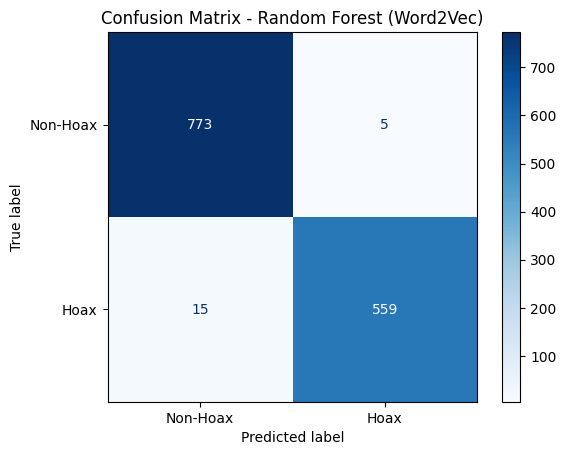

In [ ]:
# ================================================================
# 3️⃣ TRAINING MODEL RANDOM FOREST (WORD2VEC)
# ================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Inisialisasi model Random Forest
rf_w2v = RandomForestClassifier(
    n_estimators=200,     # jumlah pohon
    random_state=42,
    n_jobs=-1             # gunakan semua core CPU
)

print("Melatih model Random Forest dengan Word2Vec...")
rf_w2v.fit(X_train_w2v, y_train_w2v)

# Prediksi pada data uji
y_pred_rf_w2v = rf_w2v.predict(X_test_w2v)

# Evaluasi performa model
acc_rf_w2v = accuracy_score(y_test_w2v, y_pred_rf_w2v)
report_rf_w2v = classification_report(y_test_w2v, y_pred_rf_w2v, target_names=["Non-Hoax", "Hoax"])

print("\n✅ Model Random Forest (Word2Vec) berhasil dilatih!")
print(f"🎯 Akurasi: {acc_rf_w2v:.4f}")
print("\n📊 Classification Report:")
print(report_rf_w2v)

# ================================================================
# 🔹 CONFUSION MATRIX UNTUK RANDOM FOREST (WORD2VEC)
# ================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Hitung confusion matrix
cm_rf_w2v = confusion_matrix(y_test_w2v, y_pred_rf_w2v)
print("🧩 Confusion Matrix (Random Forest - Word2Vec):\n", cm_rf_w2v)

# Visualisasi confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_w2v, display_labels=["Non-Hoax", "Hoax"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Random Forest (Word2Vec)")
plt.grid(False)
plt.show()


# VISUALISASI PERBANDINGAN MODEL TF-IDF vs WORD2VEC

/tmp/ipython-input-4291069896.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="coolwarm")


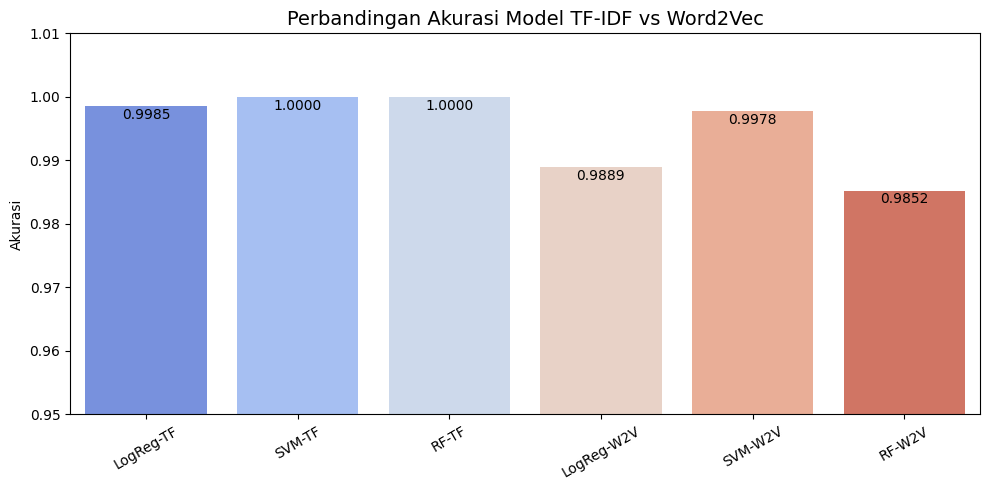

In [ ]:
# ================================================================
# 📌 PREPARASI: Pastikan prediksi TF-IDF tersedia
# ================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# =======================
# 1️⃣ Logistic Regression TF-IDF
# =======================
if 'y_pred_logreg_tfidf' not in globals():
    logreg_tfidf = LogisticRegression(max_iter=1000, random_state=42)
    logreg_tfidf.fit(X_train_sel, y_train_sel)
    y_pred_logreg_tfidf = logreg_tfidf.predict(X_test_sel)
    acc_logreg_tfidf = accuracy_score(y_test_sel, y_pred_logreg_tfidf)

# =======================
# 2️⃣ SVM TF-IDF
# =======================
if 'y_pred_svm_tfidf' not in globals():
    svm_tfidf = LinearSVC(random_state=42)
    svm_tfidf.fit(X_train_sel, y_train_sel)
    y_pred_svm_tfidf = svm_tfidf.predict(X_test_sel)
    acc_svm_tfidf = accuracy_score(y_test_sel, y_pred_svm_tfidf)

# =======================
# 3️⃣ Random Forest TF-IDF
# =======================
if 'y_pred_rf_tfidf' not in globals():
    rf_tfidf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_tfidf.fit(X_train_sel, y_train_sel)
    y_pred_rf_tfidf = rf_tfidf.predict(X_test_sel)
    acc_rf_tfidf = accuracy_score(y_test_sel, y_pred_rf_tfidf)



# ================================================================
# 📊 5️⃣ Visualisasi Perbandingan Akurasi
# ================================================================
model_names = ["LogReg-TF", "SVM-TF", "RF-TF", "LogReg-W2V", "SVM-W2V", "RF-W2V"]
accuracies = [
    acc_logreg_tfidf,
    acc_svm_tfidf,
    acc_rf_tfidf,
    acc_logreg_w2v,
    acc_svm_w2v,
    acc_rf_w2v
]

plt.figure(figsize=(10, 5))
sns.barplot(x=model_names, y=accuracies, palette="coolwarm")
plt.title("Perbandingan Akurasi Model TF-IDF vs Word2Vec", fontsize=14)
plt.ylabel("Akurasi")
plt.ylim(0.95, 1.01)
plt.xticks(rotation=30)

for i, acc in enumerate(accuracies):
    plt.text(i, acc - 0.002, f"{acc:.4f}", ha='center', color='black')

plt.tight_layout()
plt.show()


# **I. Pembangunan Model Deep Learning**

# 1. Pembangunan Model Multi-Layer Perceptron dengan Representasi Fitur TF-IDF

Loaded shapes: (6226, 2000) (1352, 2000) (6226,) (1352,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,024,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,188,865 (4.54 MB)

 Trainable params: 1,188,865 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


195/195 - 360s - 2s/step - accuracy: 0.9863 - loss: 0.0673 - val_accuracy: 0.9993 - val_loss: 9.6790e-04
Epoch 2/50
195/195 - 172s - 882ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.9993 - val_loss: 0.0011
Epoch 3/50
195/195 - 144s - 736ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9993 - val_loss: 0.0014
Epoch 4/50
195/195 - 90s - 461ms/step - accuracy: 0.9998 - loss: 8.7064e-04 - val_accuracy: 0.9993 - val_loss: 0.0017
Epoch 5/50
195/195 - 78s - 400ms/step - accuracy: 0.9998 - loss: 7.9654e-04 - val_accuracy: 0.9985 - val_loss: 0.0023
Epoch 6/50
195/195 - 53s - 271ms/step - accuracy: 0.9998 - loss: 5.2418e-04 - val_accuracy: 0.9985 - val_loss: 0.0076
MLP (TF-IDF) Test Accuracy: 0.9993
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step


              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[777   1]
 [  0 574]]


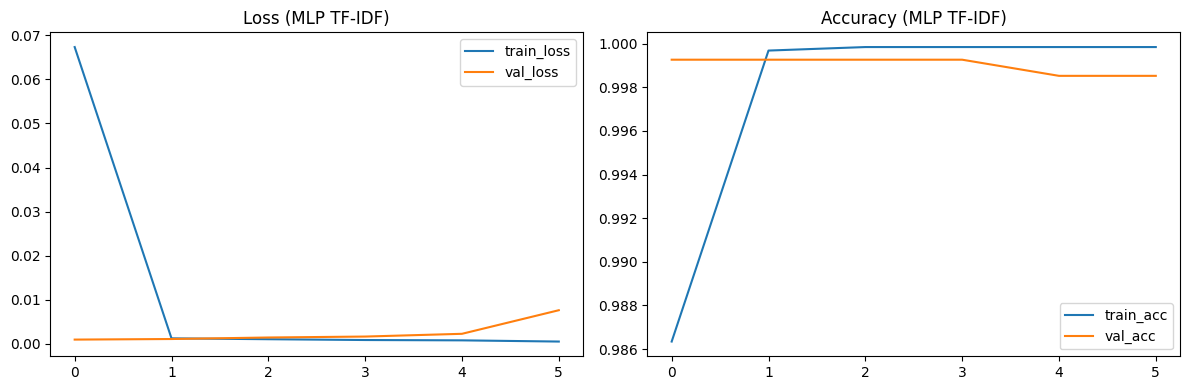

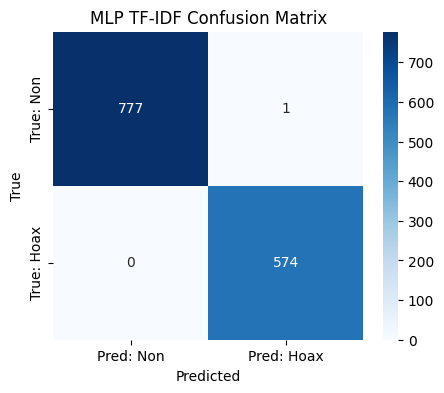

In [ ]:
# ===== MLP (TF-IDF, fitur hasil SelectKBest chi2) =====
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Load selected features (Chi2) ----------
X_train, X_test, y_train, y_test = joblib.load("selected_features_chi2.joblib")
print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Ensure numpy arrays
if not isinstance(X_train, (np.ndarray,)):
    X_train = X_train.astype(np.float32)
if not isinstance(X_test, (np.ndarray,)):
    X_test = X_test.astype(np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

# ---------- 2. Build MLP ----------
input_dim = X_train.shape[1]
model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------- 3. Callbacks ----------
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint("mlp_tfidf_best.h5", monitor='val_loss', save_best_only=True)

# ---------- 4. Train ----------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es, mc],
    verbose=2
)

# ---------- 5. Evaluate ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"MLP (TF-IDF) Test Accuracy: {acc:.4f}")

y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Non-Hoax", "Hoax"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ---------- 6. Save model + history ----------
model.save("mlp_tfidf_final.h5")
joblib.dump(history.history, "mlp_tfidf_history.joblib")

# ---------- 7. Plot training curves ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss (MLP TF-IDF)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy (MLP TF-IDF)')
plt.legend()
plt.tight_layout()
plt.savefig("mlp_tfidf_training_curves.png", dpi=150)
plt.show()

# ---------- 8. Confusion matrix heatmap (save) ----------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred: Non","Pred: Hoax"], yticklabels=["True: Non","True: Hoax"])
plt.title("MLP TF-IDF Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig("mlp_tfidf_confusion.png", dpi=150)
plt.show()


# 2. Pembangunan Model BiLSTM dengan Representasi Word2Vec

Vocab size (used): 30001
Word2Vec dim: 100
Embedding matrix shape: (30001, 100)
Train/test shapes: (5408, 120) (1352, 120)
Class weights: {0: np.float64(0.8686154834564729), 1: np.float64(1.1782135076252724)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,100 (11.44 MB)

 Trainable params: 0 (0.00 B)

...

85/85 - 16s - 190ms/step - accuracy: 0.9861 - loss: 0.0634 - val_accuracy: 0.9970 - val_loss: 0.0108
Epoch 2/15


85/85 - 3s - 35ms/step - accuracy: 0.9976 - loss: 0.0104 - val_accuracy: 0.9993 - val_loss: 0.0047
Epoch 3/15


85/85 - 4s - 46ms/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 4/15


85/85 - 3s - 31ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9993 - val_loss: 0.0026
Epoch 5/15
85/85 - 3s - 34ms/step - accuracy: 0.9919 - loss: 0.0306 - val_accuracy: 0.9719 - val_loss: 0.1168
Epoch 6/15
85/85 - 2s - 25ms/step - accuracy: 0.9871 - loss: 0.0412 - val_accuracy: 0.9948 - val_loss: 0.0163
Epoch 7/15
85/85 - 4s - 45ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9948 - val_loss: 0.0149
Epoch 8/15
85/85 - 4s - 45ms/step - accuracy: 0.9982 - loss: 0.0049 - val_accuracy: 0.9956 - val_loss: 0.0107
BiLSTM Test Accuracy: 0.9992603659629822
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[777   1]
 [  0 574]]


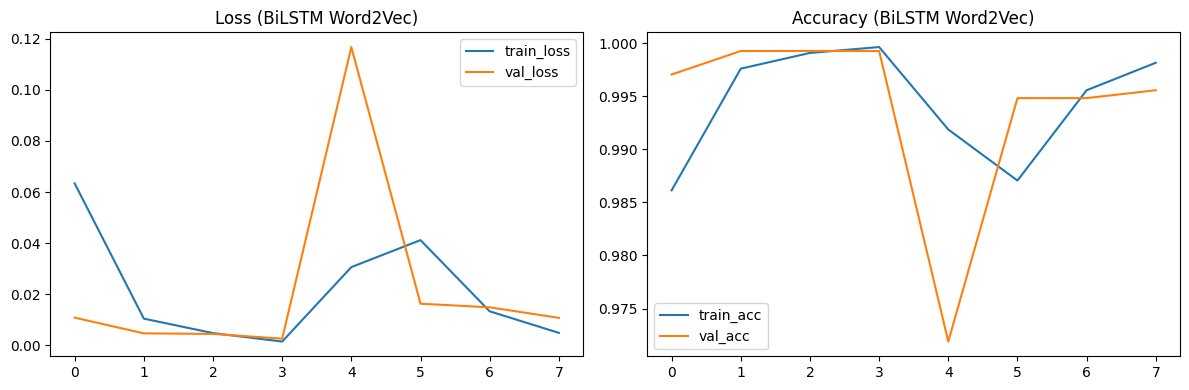

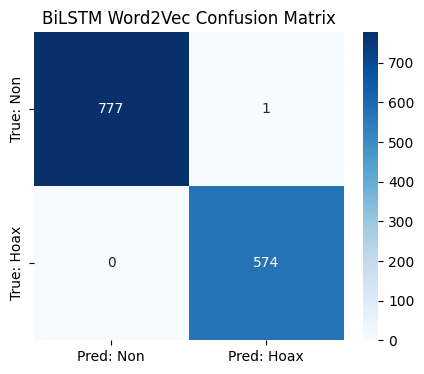

In [ ]:
# ===== LSTM (Word2Vec) using embedding matrix from gensim model =====
import numpy as np
import pandas as pd
from gensim.models import Word2Vec, KeyedVectors
import joblib
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Load data & gensim model ----------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")  # <-- path from your upload
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values

# ---------- 2. Tokenizer ----------
MAX_VOCAB = 30000   # or None to use entire
tok = Tokenizer(oov_token="<OOV>", num_words=MAX_VOCAB)
tok.fit_on_texts(texts)
word_index = tok.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1
print("Vocab size (used):", vocab_size)

# ---------- 3. Load Word2Vec (gensim) ----------
w2v_model = Word2Vec.load("word2vec_model.model")  # ensure this file exists
embed_dim = w2v_model.vector_size
print("Word2Vec dim:", embed_dim)

# ---------- 4. Build embedding matrix ----------
embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
# save embedding for re-use
np.save("embedding_matrix_w2v.npy", embedding_matrix)
print("Embedding matrix shape:", embedding_matrix.shape)

# ---------- 5. Convert texts -> sequences ----------
sequences = tok.texts_to_sequences(texts)
MAXLEN = 120  # choose based on distribution of doc lengths
X = pad_sequences(sequences, maxlen=MAXLEN, padding='post', truncating='post')
y = labels

# ---------- 6. Train-test split (stratify) ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# ---------- 7. Compute class weights to handle imbalance ----------
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i : class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weight_dict)

# ---------- 8. Build BiLSTM model ----------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_dim, weights=[embedding_matrix], input_length=MAXLEN, trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------- 9. Callbacks ----------
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
mc = ModelCheckpoint("bilstm_w2v_best.h5", monitor='val_loss', save_best_only=True)

# ---------- 10. Train ----------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[es, mc],
    verbose=2
)

# ---------- 11. Evaluate ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("BiLSTM Test Accuracy:", acc)

y_proba = model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["Non-Hoax", "Hoax"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ---------- 12. Save artifacts ----------
model.save("bilstm_w2v_final.h5")
joblib.dump(tok, "tokenizer_w2v.joblib")
np.save("embedding_matrix_w2v.npy", embedding_matrix)
joblib.dump(history.history, "bilstm_w2v_history.joblib")

# ---------- 13. Plot training curves & confusion ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss (BiLSTM Word2Vec)')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy (BiLSTM Word2Vec)')
plt.legend()
plt.tight_layout()
plt.savefig("bilstm_w2v_training_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred: Non","Pred: Hoax"], yticklabels=["True: Non","True: Hoax"])
plt.title("BiLSTM Word2Vec Confusion Matrix")
plt.savefig("bilstm_w2v_confusion.png", dpi=150)
plt.show()


# J. Pembangunan Model Transfer Learning Menggunakan IndoBERT (Fine-Tuned)

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets tokenizers accelerate scikit-learn seqeval


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ================================================================
# 0) INSTALL PACKAGE (WAJIB JALANKAN SEKALI)
# ================================================================
!pip install -q transformers==4.30.0 datasets==2.12.0 accelerate
import os
os.environ["WANDB_DISABLED"] = "true"   # matikan wandb


# ================================================================
# 1) IMPORT LIBRARY
# ================================================================
import random, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset


# ================================================================
# 2) KONFIGURASI
# ================================================================
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
SEED = 42
OUTPUT_DIR = "./indobert_hoax"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ================================================================
# 3) LOAD DATASET
# Pastikan file memiliki kolom: teks_final, label_num
# ================================================================
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")

print("Total data:", df.shape)
print(df.head())

df["label_num"] = df["label_num"].astype(int)


# ================================================================
# 4) TRAIN / TEST SPLIT
# ================================================================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_num"],
    random_state=SEED
)

print("Train:", train_df.shape, "Test:", test_df.shape)


# ================================================================
# 5) CONVERT KE DATASET HUGGINGFACE
# ================================================================
train_ds = Dataset.from_pandas(
    train_df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
)

test_ds = Dataset.from_pandas(
    test_df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
)


# ================================================================
# 6) LOAD TOKENIZER & MODEL INDO-BERT
# ================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


# ================================================================
# 7) TOKENISASI
# ================================================================
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text"])
test_ds  = test_ds.remove_columns(["text"])

train_ds.set_format("torch")
test_ds.set_format("torch")


# ================================================================
# 8) TRAINING ARGUMENTS (VERSI KOMPATIBEL)
# Tanpa evaluation_strategy karena versi Transformers Anda tidak mendukung
# ================================================================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
)


# ================================================================
# 9) DEFINE TRAINER
# ================================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer
)


# ================================================================
# 10) TRAIN MODEL
# ================================================================
trainer.train()


# ================================================================
# 11) MANUAL EVALUATION (KARENA TRAINING ARGUMENT MINIMAL)
# ================================================================
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = pred.label_ids

print("\n====================")
print("EVALUATION RESULT")
print("====================")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Hoax","Hoax"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# ================================================================
# 12) SAVE MODEL
# ================================================================
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nModel saved to:", OUTPUT_DIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 10.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projec

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Map:   0%|          | 0/5408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1352 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-314268730.py:125: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.051100
200,0.006200
300,0.009800
400,0.000100
500,0.000100
600,0.009800
700,0.000100
800,0.000000
900,0.000000
1000,0.000000



EVALUATION RESULT
Accuracy : 1.0

Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352


Confusion Matrix:
[[778   0]
 [  0 574]]

Model saved to: ./indobert_hoax


# K. Transfer Learning pada IndoBERT dengan Optimisasi LoRA

In [ ]:
# ============================
# IndoBERT + LoRA (PEFT) — Full script
# Run this in Google Colab (GPU runtime)
# ============================

# 0) (Optional) Jika tokenizers sering gagal di-build, jalankan dulu:
# !pip install tokenizers==0.13.3 --prefer-binary

# 1) Install required packages (run once)
!pip install -q transformers==4.30.0 datasets==2.12.0 accelerate peft==0.5.1

import os
os.environ["WANDB_DISABLED"] = "true"   # matikan wandb (opsional)

# 2) Imports
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from peft import LoraConfig, get_peft_model, TaskType

# 3) Config — sesuaikan sesuai kebutuhan / VRAM
MODEL_NAME = "indobenchmark/indobert-base-p2"
DATA_PATH = "dataset_ready_for_feature_extraction.csv"  # pastikan file ada
OUTPUT_DIR = "./indobert_lora"
SEED = 42

MAX_LEN = 128            # kurangi ke 96/64 bila ingin lebih cepat
EPOCHS = 3
BATCH_SIZE = 16          # ubah sesuai VRAM; bila OOM turunkan ke 8/4
LR = 2e-4                # LoRA sering pakai LR sedikit lebih tinggi (1e-4..3e-4)
LORA_R = 8               # rank (8 umum dipakai)
LORA_ALPHA = 32
LORA_DROPOUT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4) Load dataset (harus memiliki kolom: teks_final, label_num)
df = pd.read_csv(DATA_PATH)
assert "teks_final" in df.columns and "label_num" in df.columns, "File harus mengandung 'teks_final' dan 'label_num'."

# keep only needed columns and ensure int labels
df = df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
df["label"] = df["label"].astype(int)

# 5) Train/test split (stratified)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train distribution:\n", train_df["label"].value_counts())
print("Test distribution:\n", test_df["label"].value_counts())

# 6) Convert to HF Dataset
train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

# 7) Tokenizer + model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Load base model (classification head will be randomly initialized)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 8) LoRA (PEFT) config and wrap
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # classification task
    inference_mode=False,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",                  # keep bias handling simple
    target_modules=["query", "key", "value"]  # for BERT-like models
)

model = get_peft_model(model, lora_config)
print("LoRA adapters added. Trainable params (approx):")
for n, p in model.named_parameters():
    if p.requires_grad:
        print(n, p.shape)

# 9) Tokenization (use dynamic padding later via DataCollator)
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

# set formats
train_ds.set_format(type="torch")
test_ds.set_format(type="torch")

# 10) Data collator (dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 11) Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

# 12) TrainingArguments — keep minimal / compatible
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),   # use mixed precision if GPU available
    remove_unused_columns=False,
)

# 13) Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 14) Train (only LoRA params will be updated)
trainer.train()

# 15) Evaluate
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = pred.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Non-Hoax","Hoax"]))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# 16) Save LoRA adapters + tokenizer (small)
model.save_pretrained(OUTPUT_DIR)             # saves base_model + adapters in peft format
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved LoRA model + tokenizer to", OUTPUT_DIR)

# Optional: To load later:
# from peft import PeftModel
# base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# lora_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
# lora_model.eval()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 3.7 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement peft==0.5.1 (from versions: 0.0.1, 0.0.2, 0.1.0, 0.2.0, 0.3.0, 0.4.0, 0.5.0, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.8.0, 0.8.1, 0.8.2, 0.9.0, 0.10.0, 0.11.0, 0.11.1, 0.12.0, 0.13.0, 0.13.1, 0.13.2, 0.14.0, 0.15.0, 0.15.1, 0.15.2, 0.16.0, 0.17.0, 0.17.1, 0.18.0rc0, 0.18.0)
ERROR: No matching distribution found for peft==0.5.1
Train distribution:
 label
0    3113
1    2295
Name: count, dtype: int64
Test distribution:
 label
0    778
1    574
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Map:   0%|          | 0/5408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1352 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2711861362.py:134: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,0.364700
100,0.007000
150,0.002300
200,0.007800
250,0.008500
300,0.001100
350,0.002100
400,0.000300
450,0.000200
500,0.000200


Accuracy: 1.0
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[778   0]
 [  0 574]]
Saved LoRA model + tokenizer to ./indobert_lora


**Visualisasi Kurva Training Loss pada Model IndoBERT dengan LoRA**

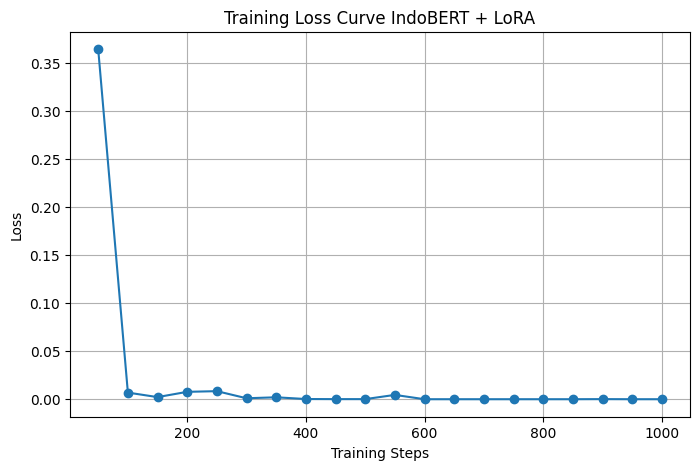

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_training_loss(trainer):
    logs = trainer.state.log_history
    steps = []
    losses = []

    for log in logs:
        if "loss" in log:
            steps.append(log["step"])
            losses.append(log["loss"])

    plt.figure(figsize=(8, 5))
    plt.plot(steps, losses, marker='o')
    plt.title("Training Loss Curve IndoBERT + LoRA")
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_training_loss(trainer)


**Visualisasi Confusion Matrix untuk Model IndoBERT dengan LoRA**

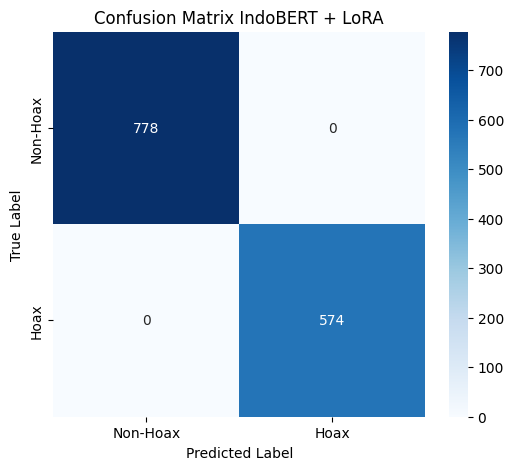

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Hoax", "Hoax"],
            yticklabels=["Non-Hoax", "Hoax"])
plt.title("Confusion Matrix IndoBERT + LoRA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Class": ["Non-Hoax", "Hoax"],
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "Support": sup
})

metrics_df


,Class,Precision,Recall,F1-score,Support
0,Non-Hoax,1.0,1.0,1.0,778
1,Hoax,1.0,1.0,1.0,574


# L. Analisis Interpretabilitas Model Menggunakan XAI

# **1. Machine Learning Klasik**

**Analisis XAI Menggunakan LIME, SHAP, dan Koefisien SVM pada Model SVM TF-IDF (Seleksi Fitur ANOVA)**

Loaded dataset, rows = 6760
Loaded tfidf_vectorizer.pkl and anova_selector.joblib
Loaded calibrated SVM from svm_tfidf_calibrated.joblib
svm_tfidf already supports predict_proba

Sample id: 10
Sample text (truncated 400 chars):
kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...

=== LIME (local) ===
Prediction (SVM calibrated): Non-Hoax
LIME top features (word -> weight):
 - raymondha            -> -0.1971
 - klaim                -> +0.1041
 - unggah               -> -0.0977
 - ktt                  -> +0.0527
 - bendera              -> -0.0497
 - akun                 -> -0.0470
 - misleading           -> -0.0432
 - lens                 ->

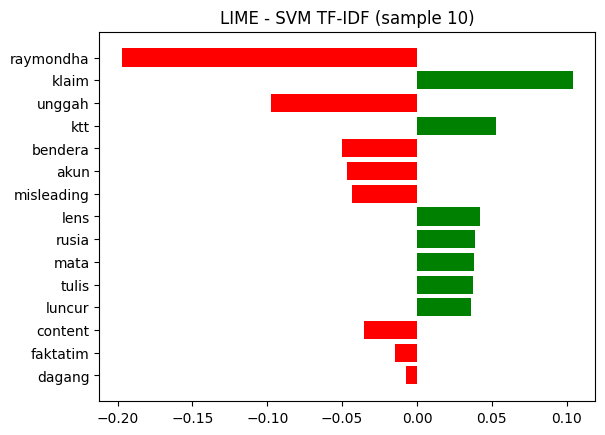


=== SHAP (LinearExplainer on TF-IDF numeric) ===

SHAP local (top 12 features for sample):
 - fattah               -> -0.0847
 - kontaminasi          -> -0.0660
 - kaya                 -> -0.0658
 - serius               -> -0.0536
 - kios                 -> -0.0489
 - raymondha            -> -0.0474
 - unggah               -> -0.0461
 - pengin               -> -0.0402
 - suhartoyo            -> -0.0390
 - jilbab               -> -0.0387
 - hektare              -> -0.0354
 - faktor               -> -0.0325

SHAP global (top 20 features):
 - fattah               -> +0.0852
 - kontaminasi          -> +0.0774
 - serius               -> +0.0746
 - kaya                 -> +0.0680
 - kios                 -> +0.0654
 - raymondha            -> +0.0590
 - unggah               -> +0.0533
 - faktor               -> +0.0517
 - mulyani              -> +0.0487
 - akun                 -> +0.0467
 - suhartoyo            -> +0.0455
 - jilbab               -> +0.0449
 - pengin               -> +0.0405
 

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
# ============================================================
# ⭐ XAI FINAL — PERBAHARUIAN: SVM + TF-IDF (ANOVA) — TIDAK ERROR
# ============================================================
# Catatan: jalankan di environment yang sudah memiliki joblib files sebelumnya.
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from lime.lime_text import LimeTextExplainer
from sklearn.calibration import CalibratedClassifierCV

# ---------------------------
# 1) Load dataset & text
# ---------------------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values
print("Loaded dataset, rows =", len(texts))

# ---------------------------
# 2) Load TF-IDF vectorizer & ANOVA selector
# ---------------------------
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")
anova_selector = joblib.load("anova_selector.joblib")
print("Loaded tfidf_vectorizer.pkl and anova_selector.joblib")

def texts_to_selected_tfidf(list_texts):
    X = tfidf_vectorizer.transform(list_texts)
    return anova_selector.transform(X)

# ---------------------------
# 3) Load SVM models
# ---------------------------
# raw_svm = original LinearSVC saved (has coef_)
raw_svm = joblib.load("svm_tfidf.joblib")   # keep raw for coef / shap linear
# svm_tfidf variable used for predict_proba (may be calibrated)
try:
    svm_tfidf = joblib.load("svm_tfidf_calibrated.joblib")
    print("Loaded calibrated SVM from svm_tfidf_calibrated.joblib")
except Exception:
    svm_tfidf = joblib.load("svm_tfidf.joblib")
    print("Loaded svm_tfidf.joblib (raw) — will calibrate if needed for predict_proba")

# If svm_tfidf doesn't support predict_proba, calibrate it (and save)
if not hasattr(svm_tfidf, "predict_proba"):
    print("svm_tfidf lacks predict_proba — calibrating now (this may take a short while)...")
    X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load("selected_features_anova.joblib")
    svm_cal = CalibratedClassifierCV(svm_tfidf, cv=3, method="sigmoid")
    svm_cal.fit(X_train_sel, y_train_sel)
    svm_tfidf = svm_cal
    joblib.dump(svm_tfidf, "svm_tfidf_calibrated.joblib")
    print("Calibrated and saved as svm_tfidf_calibrated.joblib")
else:
    print("svm_tfidf already supports predict_proba")

# ---------------------------
# 4) Pilih sample
# ---------------------------
sample_id = 10
sample_text = texts[sample_id]
print("\nSample id:", sample_id)
print("Sample text (truncated 400 chars):")
print(sample_text[:400], "...\n")

# ---------------------------
# 5) LIME local explanation
# ---------------------------
print("=== LIME (local) ===")
lime_explainer = LimeTextExplainer(class_names=["Non-Hoax","Hoax"])

def proba_fn_for_lime(texts_list):
    Xsel = texts_to_selected_tfidf(texts_list)
    return svm_tfidf.predict_proba(Xsel)

exp = lime_explainer.explain_instance(sample_text, proba_fn_for_lime, num_features=15, top_labels=1)
pred = svm_tfidf.predict(texts_to_selected_tfidf([sample_text]))[0]
print("Prediction (SVM calibrated):", "Hoax" if pred==1 else "Non-Hoax")
print("LIME top features (word -> weight):")
for w,s in exp.as_list(label=pred):
    print(f" - {w:20s} -> {s:+.4f}")

# Try to show pyplot figure if running in notebook; if not, skip
try:
    fig = exp.as_pyplot_figure(label=pred)
    plt.title("LIME - SVM TF-IDF (sample {})".format(sample_id))
    plt.show()
except Exception:
    pass

# ---------------------------
# 6) SHAP (LinearExplainer on numeric TF-IDF selected)
# ---------------------------
print("\n=== SHAP (LinearExplainer on TF-IDF numeric) ===")
# Load selected TF-IDF split for background
X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load("selected_features_anova.joblib")

# Use raw_svm (LinearSVC) for LinearExplainer to obtain meaningful coefficients-based SHAP
explainer_shap = shap.LinearExplainer(raw_svm, X_train_sel, feature_perturbation="interventional")

# Compute shap values: support both old/new APIs
try:
    shap_vals = explainer_shap.shap_values(X_test_sel)
except Exception:
    shap_exp = explainer_shap(X_test_sel)
    shap_vals = shap_exp.values  # shape: (n_samples, n_features) or list for classes

# Ensure shap_vals is array-like for class of interest.
# For binary classification, shap.LinearExplainer typically returns array (n_samples, n_features) for model output;
# if returns list (per class), pick class 1.
if isinstance(shap_vals, list):
    # shap_vals[class][sample, feature]
    shap_vals_arr = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
else:
    shap_vals_arr = shap_vals

# LOCAL SHAP: sample
sample_shap = shap_vals_arr[sample_id]
# Map feature indices back to token (selected vocab)
feature_mask = anova_selector.get_support(indices=True)
full_vocab = tfidf_vectorizer.get_feature_names_out()
selected_vocab = full_vocab[feature_mask]

print("\nSHAP local (top 12 features for sample):")
idx_local = np.argsort(np.abs(sample_shap))[::-1][:12]
for i in idx_local:
    print(f" - {selected_vocab[i]:20s} -> {sample_shap[i]:+.4f}")

# GLOBAL SHAP: mean abs across test set
print("\nSHAP global (top 20 features):")
mean_abs = np.mean(np.abs(shap_vals_arr), axis=0)
idx_global = np.argsort(mean_abs)[::-1][:20]
for i in idx_global:
    print(f" - {selected_vocab[i]:20s} -> {mean_abs[i]:+.4f}")

# ---------------------------
# 7) Feature importance from raw SVM coef_
# ---------------------------
print("\n=== Model coefficients (raw SVM) ===")
# get coef from raw_svm (LinearSVC)
if hasattr(raw_svm, "coef_"):
    coefs = raw_svm.coef_[0]
else:
    # fallback: try to extract from wrapped estimator
    try:
        coefs = svm_tfidf.base_estimator.coef_[0]
    except Exception:
        coefs = None

if coefs is not None:
    top_pos = np.argsort(coefs)[-15:][::-1]
    top_neg = np.argsort(coefs)[:15]
    print("\nTop positive (mendorong Hoax):")
    for idx in top_pos[:15]:
        print(f" - {selected_vocab[idx]:20s} -> {coefs[idx]:+.4f}")
    print("\nTop negative (mendorong Non-Hoax):")
    for idx in top_neg[:15]:
        print(f" - {selected_vocab[idx]:20s} -> {coefs[idx]:+.4f}")
else:
    print("Tidak dapat mengambil koefisien model (atribut coef_ tidak tersedia).")

print("\n=== XAI selesai ===")


**Analisis XAI Menggunakan LIME dan SHAP pada Model SVM Word2Vec (100-D)**

Loaded dataset, rows = 6760
Loaded balanced_word2vec.joblib
Calibrating SVM W2V (karena tidak ada predict_proba)...
✓ SVM W2V berhasil dikalibrasi!

=== Sample ===
kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...

🔥 LIME — Local Explanation (W2V + SVM)
Prediksi: Hoax

🔍 LIME Feature Importance:
 - konten               → +0.0183
 - klaim                → +0.0158
 - sesat                → +0.0152
 - ktt                  → -0.0119
 - misleading           → +0.0117
 - periksa              → +0.0116
 - unggah               → +0.0113
 - narasi               → +0.0099
 - content              → -0.0099
 - uang                 → -0.0084


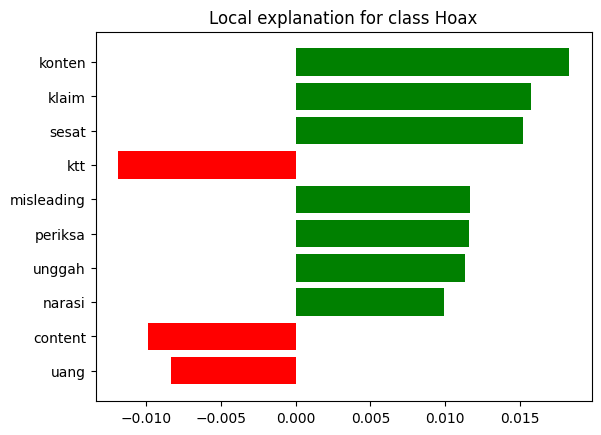


🔥 SHAP — Perbaikan: Kontribusi Per Kata (W2V)

🔍 SHAP Per-Kata (Top 15):
 - isi             → -0.8421
 - isi             → -0.8421
 - mafindo         → -0.8172
 - anggota         → -0.7037
 - anggota         → -0.7037
 - content         → +0.6305
 - content         → +0.6305
 - luncur          → -0.6142
 - luncur          → -0.6142
 - luncur          → -0.6142
 - luncur          → -0.6142
 - dagang          → -0.6137
 - india           → +0.5737
 - ribu            → -0.5439
 - komentar        → +0.5425


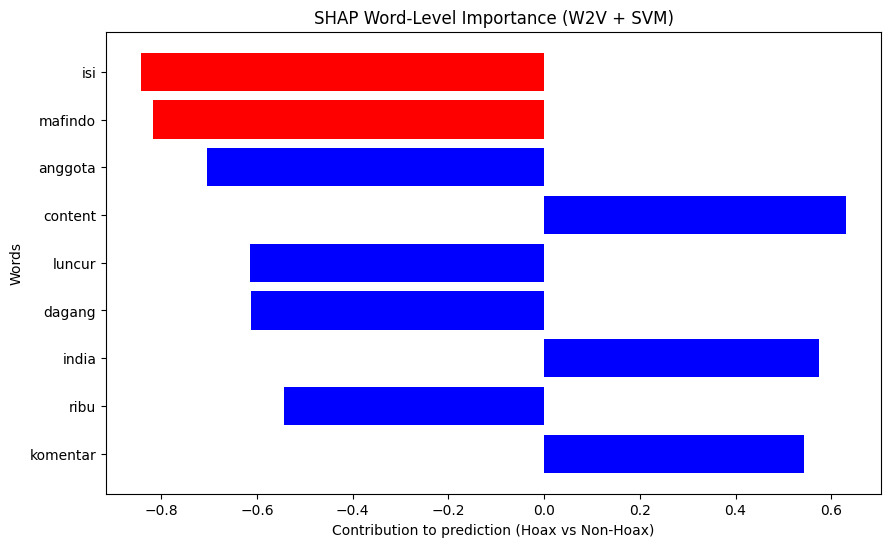

In [ ]:
# ============================================================
# ⭐ XAI — SVM + Word2Vec (100D) — FULL VERSION
# ============================================================

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from lime.lime_text import LimeTextExplainer

# ----------------------------------------
# 1) Load dataset text
# ----------------------------------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values
print("Loaded dataset, rows =", len(texts))

# ----------------------------------------
# 2) Load Word2Vec features (train/test)
# ----------------------------------------
try:
    X_train_w2v, y_train_w2v, X_test_w2v, y_test_w2v = joblib.load("balanced_word2vec.joblib")
    print("Loaded balanced_word2vec.joblib")
except:
    X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = joblib.load("word2vec_features.joblib")
    print("Loaded word2vec_features.joblib")

# ----------------------------------------
# 3) Load SVM W2V model
# ----------------------------------------
raw_svm_w2v = joblib.load("svm_w2v.joblib")  # raw model → punya coef_
svm_w2v = raw_svm_w2v

# Jika belum punya predict_proba, lakukan kalibrasi
if not hasattr(svm_w2v, "predict_proba"):
    print("Calibrating SVM W2V (karena tidak ada predict_proba)...")

    svm_cal = CalibratedClassifierCV(svm_w2v, cv=3, method="sigmoid")
    svm_cal.fit(X_train_w2v, y_train_w2v)
    svm_w2v = svm_cal
    print("✓ SVM W2V berhasil dikalibrasi!")
else:
    print("✓ SVM W2V sudah memiliki predict_proba")

# ----------------------------------------
# 4) Fungsi untuk vectorize teks → Word2Vec 100D
# ----------------------------------------
from gensim.models import Word2Vec
w2v_model = Word2Vec.load("word2vec_model.model")

def text_to_w2v_vector(text):
    words = text.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(w2v_model.vector_size)
    return np.mean(vectors, axis=0)

def texts_to_w2v(list_texts):
    return np.array([text_to_w2v_vector(t) for t in list_texts])

# ----------------------------------------
# 5) Pilih sample
# ----------------------------------------
sample_id = 10
sample_text = texts[sample_id]

print("\n=== Sample ===")
print(sample_text[:400], "...")

# ----------------------------------------
# 6) LIME Local Explanation
# ----------------------------------------
print("\n======================================")
print("🔥 LIME — Local Explanation (W2V + SVM)")
print("======================================")

lime_explainer = LimeTextExplainer(class_names=["Non-Hoax", "Hoax"])

def proba_w2v(text_list):
    X = texts_to_w2v(text_list)
    return svm_w2v.predict_proba(X)

exp = lime_explainer.explain_instance(
    sample_text,
    proba_w2v,
    num_features=10,
    top_labels=1
)

pred = svm_w2v.predict(texts_to_w2v([sample_text]))[0]
print("Prediksi:", "Hoax" if pred==1 else "Non-Hoax")

print("\n🔍 LIME Feature Importance:")
for word, score in exp.as_list(label=pred):
    print(f" - {word:20s} → {score:+.4f}")

# tampilkan grafik jika memungkinkan
try:
    fig = exp.as_pyplot_figure(label=pred)
    plt.show()
except:
    pass

print("\n======================================")
print("🔥 SHAP — Perbaikan: Kontribusi Per Kata (W2V)")
print("======================================")

# --- 1) Ambil SHAP local dari kode sebelumnya
local_shap = shap_vals[sample_id]  # shape (100,)

# --- 2) Ambil kata-kata dari teks
words = sample_text.split()
words_in_vocab = [w for w in words if w in w2v_model.wv]

if len(words_in_vocab) == 0:
    print("❌ Tidak ada kata dalam teks yang ada di vocabulary W2V.")
else:
    # --- 3) Hitung kontribusi setiap kata:
    # dot(vektor_kata, shap_vector)
    contributions = []
    for w in words_in_vocab:
        vec = w2v_model.wv[w]                    # (100,)
        score = np.dot(vec, local_shap)          # scalar
        contributions.append((w, score))

    # sort kontribusi
    contributions_sorted = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

    print("\n🔍 SHAP Per-Kata (Top 15):")
    for w, c in contributions_sorted[:15]:
        print(f" - {w:15s} → {c:+.4f}")

    # --- 4) Visualisasi bar plot SHAP per kata
    words_top = [w for w, _ in contributions_sorted[:15]]
    values_top = [c for _, c in contributions_sorted[:15]]

    plt.figure(figsize=(10, 6))
    colors = ["red" if v > 0 else "blue" for v in values_top]
    plt.barh(words_top[::-1], values_top[::-1], color=colors)
    plt.title("SHAP Word-Level Importance (W2V + SVM)")
    plt.xlabel("Contribution to prediction (Hoax vs Non-Hoax)")
    plt.ylabel("Words")
    plt.show()

# **2. Deep Learning**

**Analisis XAI Menggunakan LIME dan SHAP pada Model MLP TF-IDF**

1) Memuat data & komponen...


 - Loaded selected features (train shape (6226, 2000), test shape (1352, 2000))
 - Loaded TF-IDF vectorizer: tfidf_vectorizer.pkl
 - Loaded chi2 selector from chi2_selector.joblib
 - Selected features count: 2000

2) Memuat model MLP Keras...
 - Model loaded: mlp_tfidf_final.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
 - Quick predict (1 sample) -> (1, 2)

3) LIME — Local Explanation (per kata via mapping TF-IDF feature→kata)

Sample id: 10
Sample (truncated 300 chars): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics  ...

157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Prediksi model (MLP): Hoax

LIME — kontribusi token (top features as TF-IDF tokens):
 - faktatim                  -> +0.4981
 - konten    

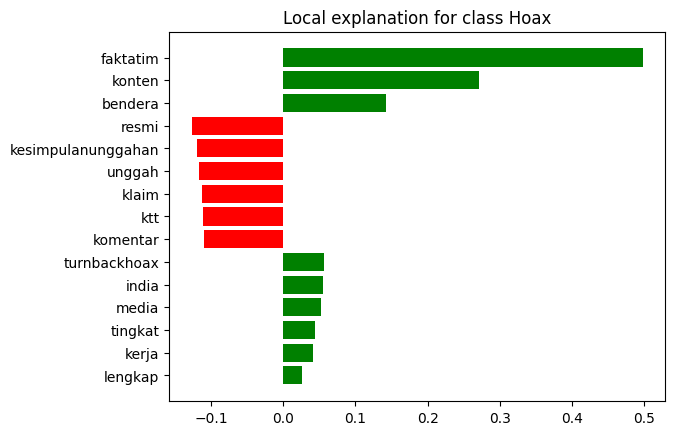

In [ ]:
# ============================================================
# XAI untuk MLP (TF-IDF + SelectKBest Chi2)
# - LIME (local, kata)
# - SHAP (global + local) via KernelExplainer pada fitur TF-IDF terpilih
# ============================================================

import os, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_text import LimeTextExplainer
from sklearn.feature_selection import SelectKBest, chi2
from tensorflow.keras.models import load_model

# ----------------------------
# Konfigurasi nama file (ganti jika beda)
# ----------------------------
MODEL_PATH = "mlp_tfidf_final.h5"                 # model Keras yang kamu simpan
SELECTED_FEATURES_FILE = "selected_features_chi2.joblib"  # berisi (X_train_chi2, X_test_chi2, y_train, y_test)
TFIDF_VECTOR_FILE = "tfidf_vectorizer.pkl"       # tfidf vectorizer sebelum seleksi
CHI2_SELECTOR_FILE = "chi2_selector.joblib"      # (opsional) file selector asli, jika ada simpan dan beri nama ini

# ----------------------------
# 1) Load dataset & komponen
# ----------------------------
print("1) Memuat data & komponen...")

# raw texts (untuk mapping fitur -> kata)
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels_all = df["label_num"].values

# load selected features (chi2)
if not os.path.exists(SELECTED_FEATURES_FILE):
    raise FileNotFoundError(f"File {SELECTED_FEATURES_FILE} tidak ditemukan. Pastikan ada di working dir.")

X_train_sel, X_test_sel, y_train_sel, y_test_sel = joblib.load(SELECTED_FEATURES_FILE)
print(f" - Loaded selected features (train shape {X_train_sel.shape}, test shape {X_test_sel.shape})")

# load TF-IDF vectorizer (sebelum selector)
if os.path.exists(TFIDF_VECTOR_FILE):
    tfidf_vec = joblib.load(TFIDF_VECTOR_FILE)
    print(" - Loaded TF-IDF vectorizer:", TFIDF_VECTOR_FILE)
else:
    raise FileNotFoundError(f"TF-IDF vectorizer not found: {TFIDF_VECTOR_FILE}")

# load or reconstruct chi2 selector
if os.path.exists(CHI2_SELECTOR_FILE):
    chi2_selector = joblib.load(CHI2_SELECTOR_FILE)
    print(" - Loaded chi2 selector from", CHI2_SELECTOR_FILE)
else:
    # reconstruct selector using k = number of selected features in X_train_sel
    K = X_train_sel.shape[1]
    print(f" - chi2 selector file not found. Reconstructing SelectKBest(chi2, k={K}) using all texts + labels.")
    # build full TF-IDF on all texts and fit selector
    X_full_tfidf = tfidf_vec.transform(texts)
    chi2_selector = SelectKBest(score_func=chi2, k=K)
    # Note: use labels_all (full dataset) to fit selector — may differ from original training selection
    chi2_selector.fit(X_full_tfidf, labels_all)
    # optional: save reconstructed selector for future runs
    try:
        joblib.dump(chi2_selector, CHI2_SELECTOR_FILE)
        print("   -> Reconstructed selector saved as", CHI2_SELECTOR_FILE)
    except Exception:
        pass

# helper: convert raw text -> selected TF-IDF features (same shape as model input)
def texts_to_selected_tfidf(list_texts):
    Xt = tfidf_vec.transform(list_texts)
    Xsel = chi2_selector.transform(Xt)
    return Xsel

# mapping index of selected feature -> original tfidf token name
full_vocab = tfidf_vec.get_feature_names_out()
selected_idx = chi2_selector.get_support(indices=True)
selected_feature_names = full_vocab[selected_idx]   # length = K

print(f" - Selected features count: {len(selected_feature_names)}")

# ----------------------------
# 2) Load MLP model
# ----------------------------
print("\n2) Memuat model MLP Keras...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file tidak ditemukan: {MODEL_PATH}")
model = load_model(MODEL_PATH)
print(" - Model loaded:", MODEL_PATH)
# ensure predict_proba wrapper
def model_predict_proba_texts(text_list):
    X = texts_to_selected_tfidf(text_list)
    preds = model.predict(X)
    # preds shape (n,1) with sigmoid
    if preds.ndim == 2 and preds.shape[1] == 1:
        p = preds.ravel()
        return np.vstack([1-p, p]).T
    elif preds.ndim==1:
        p = preds
        return np.vstack([1-p, p]).T
    else:
        return preds  # already probs

# quick sanity predict
print(" - Quick predict (1 sample) ->", model_predict_proba_texts([texts[0]]).shape)

# ----------------------------
# 3) LIME — local explanation (token-level)
# ----------------------------
print("\n3) LIME — Local Explanation (per kata via mapping TF-IDF feature→kata)")
explainer = LimeTextExplainer(class_names=["Non-Hoax","Hoax"])

# select sample
sample_id = 10
sample_text = texts[sample_id]
print("\nSample id:", sample_id)
print("Sample (truncated 300 chars):", sample_text[:300], "...\n")

# LIME needs a function that accepts list[str] -> prob array
def lime_fn(texts_in):
    return model_predict_proba_texts(texts_in)

exp = explainer.explain_instance(sample_text, lime_fn, num_features=15, top_labels=1)

pred_label = model_predict_proba_texts([sample_text]).argmax(axis=1)[0]
print("Prediksi model (MLP):", "Hoax" if pred_label==1 else "Non-Hoax")

print("\nLIME — kontribusi token (top features as TF-IDF tokens):")
# LIME returns tokens (substrings) — we will map LIME tokens to TF-IDF features where possible
for tok, score in exp.as_list(label=pred_label):
    print(f" - {tok:25s} -> {score:+.4f}")

# try show plot (not required)
try:
    fig = exp.as_pyplot_figure(label=pred_label)
    plt.show()
except Exception:
    pass


**Analisis XAI Menggunakan LIME dan SHAP pada Model BiLSTM Word2Vec**

1) Memuat model & tokenizer & embedding...


 - model: bilstm_w2v_final.h5
 - tokenizer: tokenizer_w2v.joblib
 - embedding shape: (30001, 100)

==================== EXPLAIN FULL ====================

--- LIME: Local explanation ---
Text (truncated): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia na ...

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Model prediction (LIME): Hoax

LIME top token contributions:
 - konten                         -> +0.0822
 - sesat                          -> +0.0777
 - klaim                          -> +0.0730
 - periksa                        -> +0.0644
 - misleading                     -> +0.0630
 - unggah                         -> +0.0439
 - isi                       

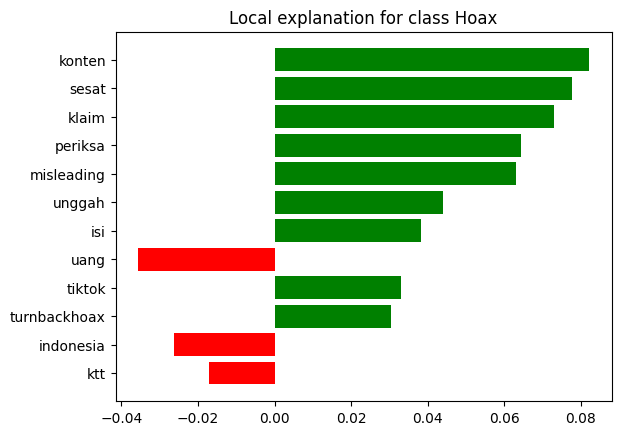


--- SHAP: explanation (DeepExplainer preferred) ---
 - DeepExplainer failed: 'NoneType' object has no attribute 'numpy'
 - Falling back to KernelExplainer (slower).
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
 - KernelExplainer done (nsamples= 100 ).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Model prediction (SHAP): Hoax  | proba: [1.3363361e-04 9.9986637e-01]

Top token contributions (SHAP) — token -> value (signed):
 - kesah           -> +0.0000 (mendorong Hoax)
 - indonesia       -> +0.0000 (mendorong Hoax)
 - klaim           -> -0.0000 (mendorong Non-Hoax)
 - potret          -> -0.0000 (mendorong Non-Hoax)
 - ulang           -> -0.0000 (mendorong Non-Hoax)
 - unggah          -> -0.0000 (mendorong Non-Hoax)
 - com             -> -0.0000 (mendorong Non-Hoax)
 - unggah          -> +0.0000 (mendorong Hoax)
 - arsip           -> -0.0000 (mendorong Non-Hoax)
 - kesah           -> +0.0000 (mendorong Non-Hoax)
 - mata            -> +0.0000 (mendorong Non-Hoax)
 - uang            -> +0.0000 (mendorong Non-Hoax)
 - resmi           -> +0.0000 (mendorong Non-Hoax)
 - brics           -> +0.0000 (mendorong Non-Hoax)
 - isi    

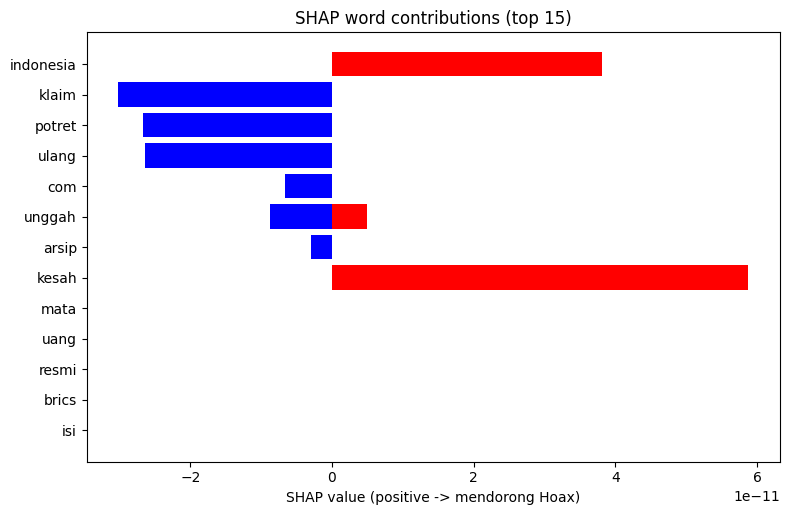


==================== DONE ====================


In [ ]:
# ============================================================
# XAI untuk BiLSTM (Word2Vec) — LIME + SHAP (token-level)
# ============================================================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lime.lime_text import LimeTextExplainer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# -----------------------------
# Config & load artifacts
# -----------------------------
MODEL_PATH = "bilstm_w2v_final.h5"
TOKENIZER_PATH = "tokenizer_w2v.joblib"
EMBED_MATRIX_PATH = "embedding_matrix_w2v.npy"

MAXLEN = 120  # must match training (kode trainingmu memakai 120)

print("1) Memuat model & tokenizer & embedding...")
model = load_model(MODEL_PATH)
tokenizer = joblib.load(TOKENIZER_PATH)
embedding_matrix = np.load(EMBED_MATRIX_PATH)

print(" - model:", MODEL_PATH)
print(" - tokenizer:", TOKENIZER_PATH)
print(" - embedding shape:", embedding_matrix.shape)

# load raw texts for mapping token->word
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values

# helper: convert text list -> padded sequences (same preprocessing as training)
def texts_to_padded_seq(list_texts, maxlen=MAXLEN):
    seqs = tokenizer.texts_to_sequences(list_texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

# helper: model predict_proba wrapper (returns Nx2 probabilities)
def model_predict_proba_from_seqs(X_seq):
    # X_seq should be numpy array shape (n, MAXLEN)
    preds = model.predict(X_seq)
    # sigmoid output shape (n,1) -> produce two-column probabilities
    if preds.ndim == 2 and preds.shape[1] == 1:
        p = preds.ravel()
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return np.vstack([1-p, p]).T
    elif preds.ndim == 1:
        p = preds
        p = np.clip(p, 1e-7, 1 - 1e-7)
        return np.vstack([1-p, p]).T
    else:
        return preds

def model_predict_proba_from_texts(texts_list):
    X = texts_to_padded_seq(texts_list)
    return model_predict_proba_from_seqs(X)

# helper: map sequence (list of token ids) -> token strings (exclude padding 0)
def seq_to_tokens(seq):
    index_word = tokenizer.index_word if hasattr(tokenizer, "index_word") else None
    if index_word is None:
        # fallback: build index_word from tokenizer.word_index
        index_word = {v:k for k,v in tokenizer.word_index.items()}
    tokens = [index_word.get(int(tok), "?") for tok in seq if int(tok) != 0]
    return tokens

# -----------------------------
# LIME — local explanation
# -----------------------------
def explain_lime(text, num_features=12, label_names=["Non-Hoax","Hoax"]):
    print("\n--- LIME: Local explanation ---")
    print("Text (truncated):", text[:350], "...\n")
    explainer = LimeTextExplainer(class_names=label_names)
    # lime expects function list[str] -> 2-col probs
    exp = explainer.explain_instance(text, model_predict_proba_from_texts, num_features=num_features, top_labels=1)
    pred_label = model_predict_proba_from_texts([text]).argmax(axis=1)[0]
    print("Model prediction (LIME):", "Hoax" if pred_label==1 else "Non-Hoax")
    print("\nLIME top token contributions:")
    for tok,score in exp.as_list(label=pred_label):
        print(f" - {tok:30s} -> {score:+.4f}")
    # try show figure
    try:
        fig = exp.as_pyplot_figure(label=pred_label)
        plt.show()
    except Exception:
        pass
    return exp, pred_label

# -----------------------------
# SHAP — DeepExplainer (preferred) or KernelExplainer fallback
# -----------------------------
def explain_shap(text, background_texts=None, nsamples=100):
    """
    Explain a single text.
    background_texts: list of texts used as background (if None, sample from texts)
    Returns: dict with tokens, token_shap_values (signed), pred_label, pred_proba
    """
    print("\n--- SHAP: explanation (DeepExplainer preferred) ---")
    sample_seq = texts_to_padded_seq([text])
    # prepare background sequences
    if background_texts is None:
        # pick 100 random training texts as background (or all if small)
        rng = np.random.default_rng(42)
        n_bg = min(200, len(texts))
        bg_inds = rng.choice(len(texts), size=n_bg, replace=False)
        background_texts = [texts[i] for i in bg_inds]
    X_bg = texts_to_padded_seq(background_texts)

    # Try DeepExplainer (works best for TF/Keras)
    use_deep = True
    shap_values = None
    try:
        # DeepExplainer expects a model and background tensors
        dee = shap.DeepExplainer(model, X_bg[:50])  # limit background for performance
        shap_out = dee.shap_values(sample_seq)  # may produce list (per class) or array
        shap_values = shap_out
        print(" - DeepExplainer succeeded.")
    except Exception as e:
        print(" - DeepExplainer failed:", e)
        print(" - Falling back to KernelExplainer (slower).")
        # KernelExplainer expects a function mapping numeric array -> probs
        ke = shap.KernelExplainer(lambda x: model_predict_proba_from_seqs(x), X_bg[:50])
        shap_out = ke.shap_values(sample_seq, nsamples=nsamples)
        shap_values = shap_out
        use_deep = False
        print(" - KernelExplainer done (nsamples=", nsamples, ").")

    # shap_out may be:
    # - list of arrays per class: shap_out[class][sample, seq_len, embed_dim?] or [sample, seq_len]
    # - or array shape (sample, seq_len, embed_dim) for regression
    # Choose class 1 (Hoax) if list
    if isinstance(shap_values, list):
        # pick class 1 if exists, else take first
        idx_class = 1 if len(shap_values) > 1 else 0
        vals = np.array(shap_values[idx_class])
    else:
        vals = np.array(shap_values)

    # vals shape possibilities:
    # (n_samples, seq_len, embed_dim) OR (n_samples, seq_len)
    vals = np.array(vals)
    if vals.ndim == 3:
        # sum across embedding dimension to obtain per-token contribution
        per_token = vals.sum(axis=2)[0]   # first (and only) sample
    elif vals.ndim == 2:
        per_token = vals[0]
    else:
        raise RuntimeError("Unhandled shap values shape: " + str(vals.shape))

    # Map sequence tokens to token strings (exclude padded zeros)
    seq = sample_seq[0]
    tokens = []
    token_shap = []
    for t, s in zip(seq, per_token):
        if int(t) == 0:
            # padding: skip
            continue
        tokens.append(tokenizer.index_word.get(int(t), "?"))
        token_shap.append(float(s))

    # pair and sort by absolute contribution
    pairs = list(zip(tokens, token_shap))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    pred_proba = model_predict_proba_from_texts([text])[0]
    pred_label = int(np.argmax(pred_proba))

    print("Model prediction (SHAP):", "Hoax" if pred_label==1 else "Non-Hoax", " | proba:", pred_proba)
    print("\nTop token contributions (SHAP) — token -> value (signed):")
    for tok, val in pairs_sorted[:20]:
        direction = "mendorong Hoax" if val > 0 else "mendorong Non-Hoax"
        print(f" - {tok:15s} -> {val:+.4f} ({direction})")

    # plot top 15
    topN = min(15, len(pairs_sorted))
    top_tokens = [p[0] for p in pairs_sorted[:topN]][::-1]
    top_vals   = [p[1] for p in pairs_sorted[:topN]][::-1]
    colors = ["red" if v>0 else "blue" for v in top_vals]
    plt.figure(figsize=(8, max(3, topN*0.35)))
    plt.barh(top_tokens, top_vals, color=colors)
    plt.title("SHAP word contributions (top {})".format(topN))
    plt.xlabel("SHAP value (positive -> mendorong Hoax)")
    plt.tight_layout()
    plt.show()

    return {
        "tokens": tokens,
        "token_shap": token_shap,
        "pairs_sorted": pairs_sorted,
        "pred_label": pred_label,
        "pred_proba": pred_proba,
        "used_deep": use_deep
    }

# -----------------------------
# Convenience: explain both
# -----------------------------
def explain_full(text, background_texts=None, nsamples=100):
    print("\n==================== EXPLAIN FULL ====================")
    exp_lime, pred_lime = explain_lime(text)
    res_shap = explain_shap(text, background_texts=background_texts, nsamples=nsamples)
    print("\n==================== DONE ====================")
    return {"lime": exp_lime, "lime_pred": pred_lime, "shap": res_shap}

# -----------------------------
# USAGE: contoh
# -----------------------------
sample_id = 10
sample_text = texts[sample_id]

# Jalankan LIME + SHAP untuk sample ini:
res = explain_full(sample_text, background_texts=texts[:300], nsamples=100)

# Kalau mau menjelaskan teks lain, panggil:
# explain_full("teks baru di sini...", background_texts=texts[:300], nsamples=100)


# **3. Transfer Learning**

**Analisis XAI Menggunakan LIME dan SHAP pada Model IndoBERT (Transformers)**

Device: cuda
Loading tokenizer & model from ./indobert_hoax
Smoke test predict_proba on a dummy text:
[[9.9997044e-01 2.9510449e-05]]
SAMPLE (truncated): kesah mata uang resmi brics unggah isi klaim mata uang brics luncur bendera indonesia konten sesat misleading content sabtu akun tiktok unityindversity membagikanvideo arsip tampil bendera nama indonesia mata uang asosiasi brasil rusia india tiongkok afrika selatan brics video klaim mata uang brics luncur resmi konferensi tingkat ktt brics rusia narasi lengkap mata uang brics luncur resmi ktt bric ...


===== LIME explanation =====
Model prediction: Hoax

LIME top token contributions:
 - konten                    -> +0.1390
 - sesat                     -> +0.1055
 - akun                      -> +0.0716
 - narasi                    -> +0.0623
 - content                   -> +0.0419
 - klaim                     -> +0.0354
 - isi                       -> +0.0325
 - kesimpulanunggahan        -> +0.0312
 - membagikanvideo           -> +0.0

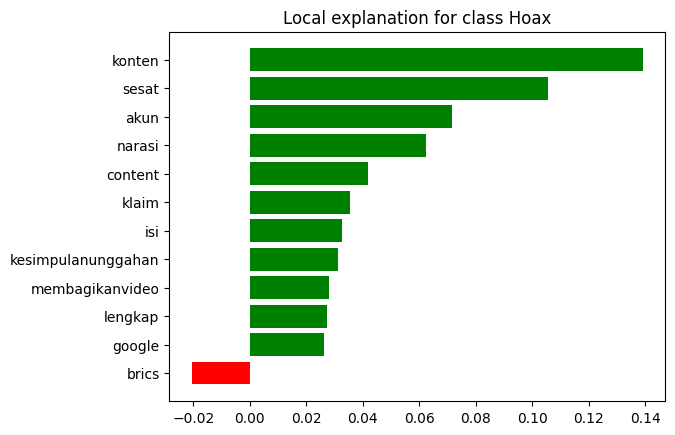


===== SHAP explanation =====
Model prediction (SHAP): Hoax | proba: [2.8378223e-05 9.9997163e-01]

Top token contributions (SHAP) — token -> value (signed):
 - lengkap              -> +0.0202 (mendorong Hoax)
 - indonesia            -> -0.0162 (mendorong Non-Hoax)
 - komentar             -> +0.0153 (mendorong Hoax)
 - ktt                  -> -0.0153 (mendorong Non-Hoax)
 - ungg                 -> +0.0153 (mendorong Hoax)
 - fakta                -> +0.0130 (mendorong Hoax)
 - fakta                -> +0.0129 (mendorong Hoax)
 - gambar               -> +0.0127 (mendorong Hoax)
 - lun                  -> -0.0114 (mendorong Non-Hoax)
 - rusia                -> -0.0106 (mendorong Non-Hoax)
 - back                 -> -0.0103 (mendorong Non-Hoax)
 - selasa               -> -0.0102 (mendorong Non-Hoax)
 - google               -> +0.0100 (mendorong Hoax)
 - resmi                -> -0.0097 (mendorong Non-Hoax)
 - bri                  -> -0.0089 (mendorong Non-Hoax)
 - bri                  -> -0.

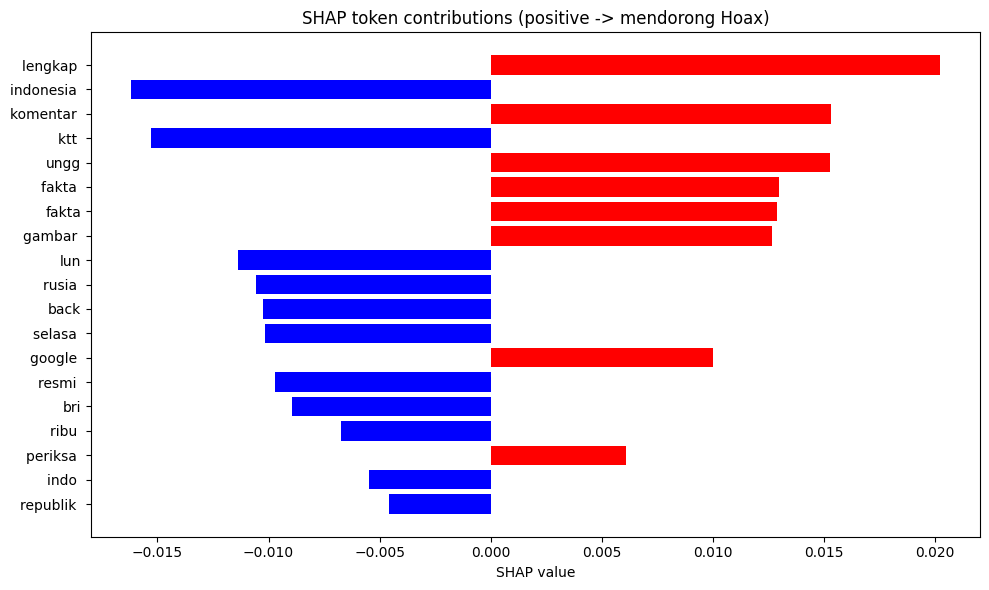

In [ ]:
# ============================================================
# XAI untuk model IndoBERT (transformers) — LIME + SHAP
# ============================================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from lime.lime_text import LimeTextExplainer
import shap
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ------------- CONFIG -------------
MODEL_DIR = "./indobert_hoax"   # folder where trainer saved model & tokenizer
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ------------- LOAD model & tokenizer -------------
print("Loading tokenizer & model from", MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

# ------------- helper: predict_proba for list[str] -------------
import torch.nn.functional as F

def model_predict_proba(texts, batch_size=16):
    """
    texts: list[str]
    returns: numpy array shape (n, 2) with probabilities for [non-hoax, hoax]
    """
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
            outputs = model(**enc)
            logits = outputs.logits  # (batch, num_labels)
            probs = F.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

# quick smoke test (optional)
print("Smoke test predict_proba on a dummy text:")
print(model_predict_proba(["uji coba model bahasa indonesia"]))

# ------------- Load raw texts (for display) -------------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")
texts = df["teks_final"].astype(str).tolist()

# ------------- LIME explanation (local) -------------
def explain_with_lime(sample_text, class_names=["Non-Hoax","Hoax"], num_features=12):
    print("\n===== LIME explanation =====")
    explainer = LimeTextExplainer(class_names=class_names)
    exp = explainer.explain_instance(sample_text, classifier_fn=model_predict_proba, num_features=num_features, top_labels=1)
    pred_label = int(model_predict_proba([sample_text]).argmax(axis=1)[0])
    print("Model prediction:", "Hoax" if pred_label==1 else "Non-Hoax")
    print("\nLIME top token contributions:")
    for tok,score in exp.as_list(label=pred_label):
        print(f" - {tok:25s} -> {score:+.4f}")
    try:
        fig = exp.as_pyplot_figure(label=pred_label)
        plt.show()
    except Exception:
        pass
    return exp, pred_label

# ------------- SHAP explanation (token-level) -------------
def explain_with_shap(sample_text, background_texts=None, nsamples=200):
    """
    Uses shap.Explainer with shap.maskers.Text(tokenizer).
    background_texts: list[str] for masker background (if None, sample from texts)
    """
    print("\n===== SHAP explanation =====")
    if background_texts is None:
        # choose up to 200 background examples (random subset)
        rng = np.random.default_rng(42)
        n_bg = min(200, len(texts))
        bg_idx = rng.choice(len(texts), size=n_bg, replace=False)
        background_texts = [texts[i] for i in bg_idx]

    # Build a wrapper that accepts a list[str] and returns class probabilities for SHAP
    def predict_fn_for_shap(x):
        # shap may pass numpy array of strings
        xlist = [str(xx) for xx in x]
        return model_predict_proba(xlist)

    # shap.maskers.Text expects a HuggingFace tokenizer object or callable tokenizer
    masker = shap.maskers.Text(tokenizer)

    explainer = shap.Explainer(predict_fn_for_shap, masker, output_names=["Non-Hoax","Hoax"])
    # run explainer on the sample (wrap in list)
    shap_explanation = explainer([sample_text])
    # shap_explanation is a ShapleyExplanation object
    # tokens:
    tokens = shap_explanation.data[0]         # list of token strings
    values = shap_explanation.values         # shape: (n_samples, n_tokens, n_classes) OR (n_samples, n_tokens) depending
    # Determine shape & extract class=1 (Hoax) contributions
    if isinstance(values, list):
        # older API: list per class
        if len(values) > 1:
            vals_for_class = np.array(values[1])[0]   # (n_tokens,)
        else:
            vals_for_class = np.array(values[0])[0]
    else:
        vals = np.array(values)
        if vals.ndim == 3:
            # (n_samples, n_tokens, n_classes) -> take class 1
            vals_for_class = vals[0,:,1]
        elif vals.ndim == 2:
            # (n_samples, n_tokens) -> signed importance (class-specific depends on explainer)
            vals_for_class = vals[0]
        else:
            raise RuntimeError("Unexpected SHAP values shape: " + str(vals.shape))

    # Pair token -> value and sort by absolute importance
    pairs = list(zip(tokens, vals_for_class))
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)

    # Print top tokens
    print("Model prediction (SHAP):", "Hoax" if model_predict_proba([sample_text]).argmax(axis=1)[0]==1 else "Non-Hoax",
          "| proba:", model_predict_proba([sample_text])[0])
    print("\nTop token contributions (SHAP) — token -> value (signed):")
    for tok, val in pairs_sorted[:20]:
        direction = "mendorong Hoax" if val > 0 else "mendorong Non-Hoax"
        print(f" - {tok:20s} -> {val:+.4f} ({direction})")

    # plot top N
    topN = min(20, len(pairs_sorted))
    top_tokens = [p[0] for p in pairs_sorted[:topN]][::-1]
    top_vals   = [p[1] for p in pairs_sorted[:topN]][::-1]
    colors = ["red" if v>0 else "blue" for v in top_vals]
    plt.figure(figsize=(10, max(3, topN*0.3)))
    plt.barh(top_tokens, top_vals, color=colors)
    plt.title("SHAP token contributions (positive -> mendorong Hoax)")
    plt.xlabel("SHAP value")
    plt.tight_layout()
    plt.show()

    return {
        "tokens": tokens,
        "vals_for_class": vals_for_class,
        "pairs_sorted": pairs_sorted,
        "shap_explanation": shap_explanation
    }

# ------------- USAGE EXAMPLE -------------
sample_id = 10
sample_text = texts[sample_id]

print("SAMPLE (truncated):", sample_text[:400], "...\n")

# run LIME
exp_lime, pred_lime = explain_with_lime(sample_text, num_features=12)

# run SHAP (this will use Deep or Partition explainer internally and should map to tokens)
res_shap = explain_with_shap(sample_text, background_texts=texts[:300], nsamples=200)


**Analisis XAI Menggunakan LIME, SHAP, Attention, dan Integrated Gradients pada Model IndoBERT + LoRA**

In [ ]:
# ==============================================
# XAI for IndoBERT + LoRA
# (LIME + SHAP + Attention + Integrated Gradients FIXED)
# ==============================================

import os, torch, numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from peft import PeftModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "indobenchmark/indobert-base-p2"
LORA_DIR = "./indobert_lora"
MAX_LEN = 128

print("Device:", DEVICE)

# -----------------------------
# Load Model + Tokenizer
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

if os.path.isdir(LORA_DIR):
    print("Loading LoRA adapter:", LORA_DIR)
    model = PeftModel.from_pretrained(base_model, LORA_DIR)
else:
    print("LoRA not found → using base model.")
    model = base_model

model.to(DEVICE)
model.eval()

# -----------------------------
# Helper: Predict Probabilities
# -----------------------------
def predict_proba(texts):
    enc = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc).logits
        p = torch.softmax(out, dim=-1).cpu().numpy()
    return p

print("Sanity check:", predict_proba(["uji coba sistem deteksi hoax"]))

# ======================================================
# 1) LIME
# ======================================================
print("\n--- LIME ---")
!pip install -q lime

from lime.lime_text import LimeTextExplainer
explainer_lime = LimeTextExplainer(class_names=["Non-Hoax", "Hoax"])

def lime_predict(x):
    return predict_proba(x)

sample_text = "Ini contoh berita palsu yang menyebut presiden melakukan X tanpa bukti."
lime_exp = explainer_lime.explain_instance(sample_text, lime_predict, num_features=10)
print("LIME:", lime_exp.as_list())

# ======================================================
# 2) SHAP (Pipeline-Compatible)
# ======================================================
print("\n--- SHAP (pipeline) ---")
!pip install -q shap==0.45.1

import shap

clf_pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if DEVICE == "cuda" else -1,
    return_all_scores=True
)

explainer_shap = shap.Explainer(clf_pipe)
shap_values = explainer_shap([sample_text])
print("SHAP computed (ready for shap.plots.text).")

# ======================================================
# 3) Attention Visualization
# ======================================================
print("\n--- Attention ---")

def get_attention(text, layer=-1):
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    attn = out.attentions[layer][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    return tokens, attn

tokens, attn_map = get_attention(sample_text, layer=-1)
print("Tokens:", tokens)
print("Attention shape:", attn_map.shape)

plt.figure(figsize=(8,6))
plt.imshow(attn_map[0], cmap="viridis")
plt.title("Attention Head 0")
plt.xticks(range(len(tokens)), tokens, rotation=90, fontsize=7)
plt.yticks(range(len(tokens)), tokens, fontsize=7)
plt.colorbar()
plt.tight_layout()
plt.show()

# ======================================================
# 4) Integrated Gradients (SAFE GPU VERSION)
# ======================================================
print("\n--- Integrated Gradients FIXED ---")

def integrated_gradients_torch(model, tokenizer, text, target_label=1, baseline_token_id=None, steps=30):
    device = next(model.parameters()).device

    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    embed_layer = model.get_input_embeddings()
    input_embeds = embed_layer(input_ids)   # (1,L,E)

    if baseline_token_id is None:
        baseline = torch.zeros_like(input_embeds)
    else:
        baseline_ids = torch.full_like(input_ids, baseline_token_id)
        baseline = embed_layer(baseline_ids)

    diff = input_embeds - baseline

    total_grads = torch.zeros_like(input_embeds).cpu()

    for k in range(1, steps + 1):
        alpha = k / steps
        emb = (baseline + alpha * diff).detach().requires_grad_(True)

        out = model(inputs_embeds=emb, attention_mask=attention_mask)
        target = out.logits[:, target_label].sum()

        grads = torch.autograd.grad(target, emb)[0]
        total_grads += grads.detach().cpu()

        del emb, out, target, grads
        torch.cuda.empty_cache()

    avg_grads = total_grads / steps
    attributions = (avg_grads.squeeze(0).numpy() * diff.squeeze(0).cpu().numpy()).sum(axis=-1)
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().cpu().numpy())

    return tokens, attributions

tokens_ig, attr_ig = integrated_gradients_torch(model, tokenizer, sample_text, target_label=1, steps=20)

print("Top IG tokens:")
for t, a in sorted(zip(tokens_ig, attr_ig), key=lambda x: -abs(x[1]))[:10]:
    print(f"{t:15} {a:.4f}")

plt.figure(figsize=(10,3))
plt.bar(range(len(attr_ig)), attr_ig)
plt.xticks(range(len(attr_ig)), tokens_ig, rotation=90, fontsize=7)
plt.title("Integrated Gradients Attribution (Hoax)")
plt.tight_layout()
plt.show()

# ======================================================
# 5) Final Combined Report
# ======================================================
def explain(text):
    print("\n====================")
    print("TEXT:", text)
    print("====================")

    probs = predict_proba([text])[0]
    print("\nProbabilities:", {"Non-Hoax": float(probs[0]), "Hoax": float(probs[1])})

    print("\n--- LIME ---")
    print(explainer_lime.explain_instance(text, lime_predict).as_list())

    print("\n--- SHAP ready (use shap.plots.text) ---")

    print("\n--- Attention tokens ---")
    toks, _ = get_attention(text)
    print(toks)

    print("\n--- IG top tokens ---")
    toks_ig, attrs = integrated_gradients_torch(model, tokenizer, text, steps=20)
    for t, a in sorted(zip(toks_ig, attrs), key=lambda x: -abs(x[1]))[:10]:
        print(f"{t:15} {a:.4f}")

# Jalankan
explain(sample_text)


Device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading LoRA adapter: ./indobert_lora
Sanity check: [[0.9777759  0.02222417]]

--- LIME ---
LIME: [(np.str_('presiden'), -0.2586793314325919), (np.str_('tanpa'), -0.25033993954876066), (np.str_('bukti'), 0.216572841620905), (np.str_('berita'), 0.1935072315792101), (np.str_('palsu'), 0.18718139305812156), (np.str_('contoh'), 0.11432713243408262), (np.str_('Ini'), -0.11121982199674588), (np.str_('menyebut'), 0.08778374426444419), (np.str_('X'), -0.08565071994481269), (np.str_('yang'), 0.009985222282148053)]

--- SHAP (pipeline) ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.3/544.3 kB 12.3 MB/s eta 0:00:00


Device set to use cuda:0


SHAP computed (ready for shap.plots.text).

--- Attention ---
Tokens: ['[CLS]', 'ini', 'contoh', 'berita', 'palsu', 'yang', 'menyebut', 'presiden', 'melakukan', 'x', 'tanpa', 'bukti', '.', '[SEP]']
Attention shape: (12, 14, 14)

--- Integrated Gradients FIXED ---
Top IG tokens:
presiden        1.8158
palsu           0.9671
bukti           0.5442
x               0.5190
tanpa           0.3857
.               0.3175
contoh          -0.2773
melakukan       0.2159
ini             0.2084
berita          -0.1645

TEXT: Ini contoh berita palsu yang menyebut presiden melakukan X tanpa bukti.

Probabilities: {'Non-Hoax': 0.6543135046958923, 'Hoax': 0.34568649530410767}

--- LIME ---
[(np.str_('tanpa'), -0.25741439643096115), (np.str_('presiden'), -0.24370634949065587), (np.str_('bukti'), 0.223524946640497), (np.str_('berita'), 0.19588563521369798), (np.str_('palsu'), 0.1910578437579652), (np.str_('contoh'), 0.11561967188317504), (np.str_('Ini'), -0.11314538064967108), (np.str_('menyebut'), 0.090

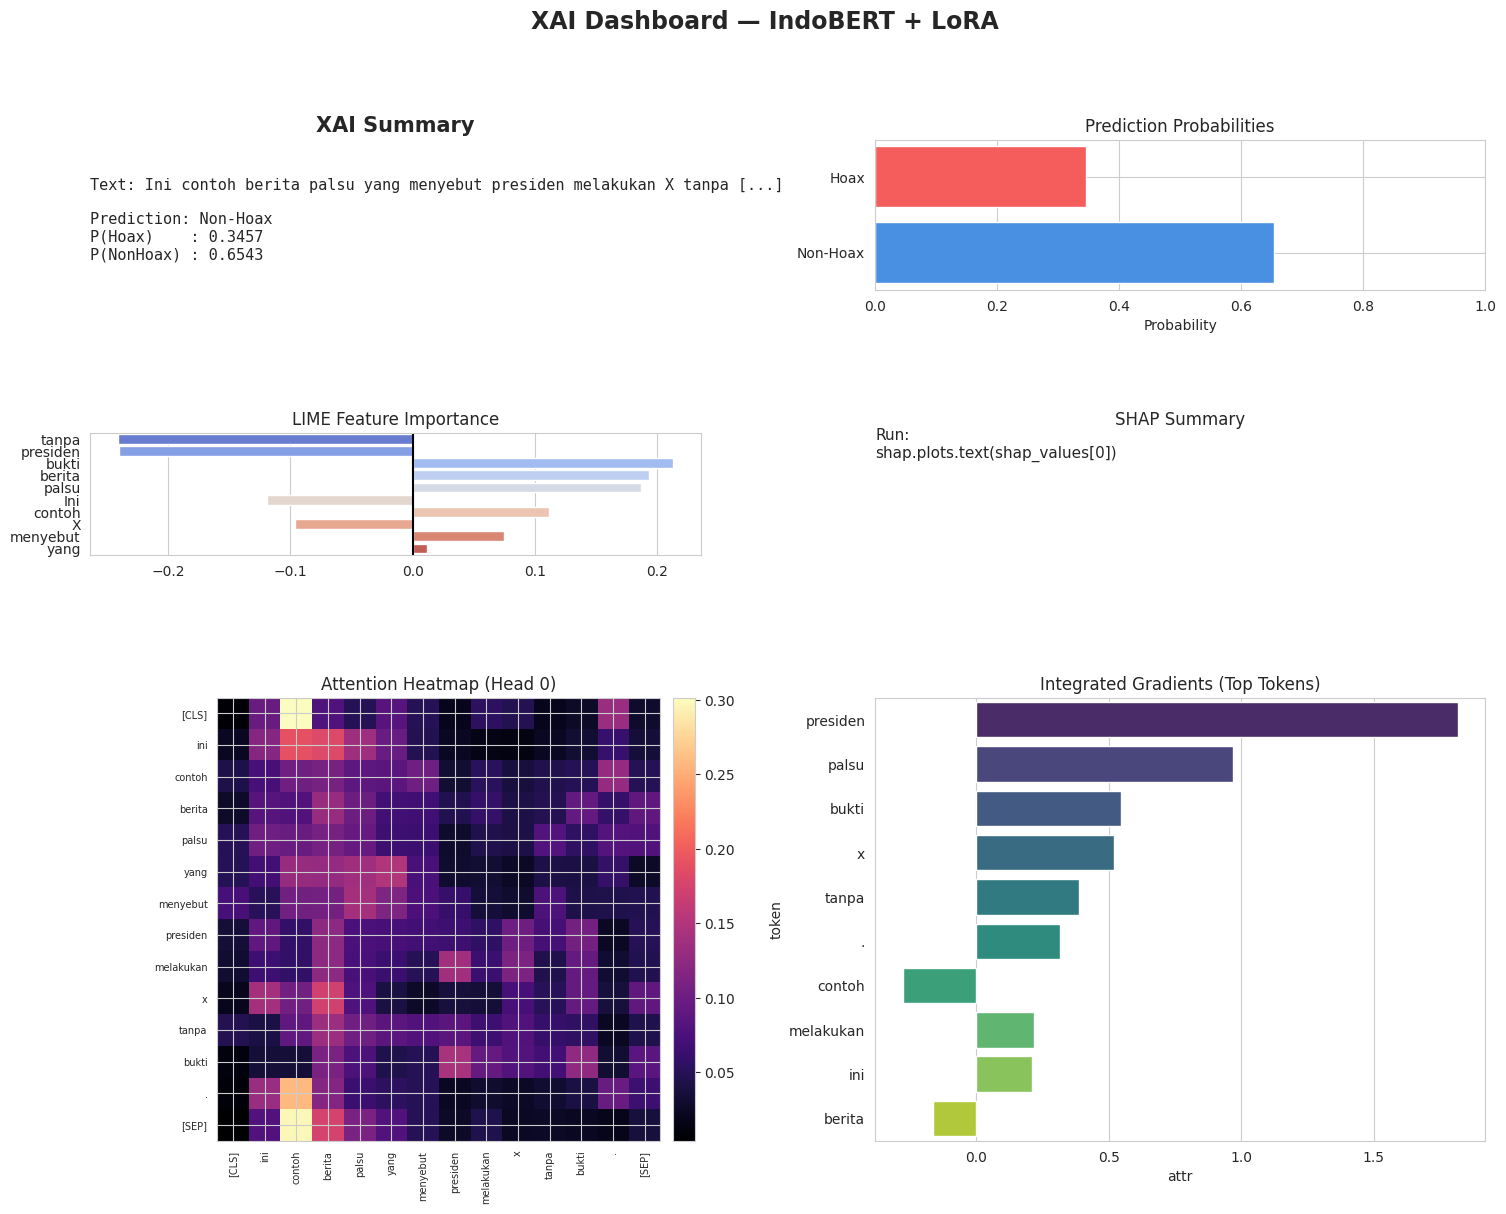


Dashboard generated successfully ✔


In [ ]:
# ==========================================
# XAI DASHBOARD — NO OVERLAP VERSION
# ==========================================

fig = plt.figure(figsize=(18, 13))

# Tinggi tiap baris diperbesar terutama baris pertama
gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1.6, 1.3, 1.6, 1.6],  # <-- baris pertama lebih tinggi
    hspace=1.0,                         # <-- jarak vertikal besar
    wspace=0.8                          # <-- jarak horizontal besar
)

# ---------------------------------------------------
# SUMMARY — kiri atas
# ---------------------------------------------------
ax0 = fig.add_subplot(gs[0, 0:2])
ax0.axis("off")
ax0.set_title("XAI Summary", fontsize=15, fontweight="bold")

# text diringkas & diberi posisi lebih turun
summary_text = (
    f"Text: {shorten(sample_text, width=70)}\n\n"
    f"Prediction: {'Hoax' if pred_label==1 else 'Non-Hoax'}\n"
    f"P(Hoax)    : {probs[1]:.4f}\n"
    f"P(NonHoax) : {probs[0]:.4f}"
)

ax0.text(
    0.0, 0.75,                          # <-- posisi TURUNKAN text agar tidak mepet
    summary_text,
    fontsize=11,
    family="monospace",
    va="top"
)


# ---------------------------------------------------
# PROBABILITIES — kanan atas (diberi margin jauh)
# ---------------------------------------------------
ax1 = fig.add_subplot(gs[0, 2:])
ax1.barh(
    ["Non-Hoax","Hoax"],
    [probs[0], probs[1]],
    color=["#4A90E2","#F55D5D"]
)
ax1.set_xlim(0,1)
ax1.set_title("Prediction Probabilities")
ax1.set_xlabel("Probability")

# beri margin lebih besar ke kiri
ax1.margins(x=0.25)                    # <-- tambahan ruang jauh dari summary


# ---------------------------------------------------
# LIME — kiri tengah
# ---------------------------------------------------
ax2 = fig.add_subplot(gs[1, 0:2])
if lime_result:
    words = [w for w, s in lime_result]
    scores = [s for w, s in lime_result]
    sns.barplot(x=scores, y=words, ax=ax2, palette="coolwarm")
    ax2.set_title("LIME Feature Importance")
    ax2.axvline(0, color="black")
else:
    ax2.text(0.1, 0.5, "LIME unavailable")
    ax2.axis("off")


# ---------------------------------------------------
# SHAP — kanan tengah
# ---------------------------------------------------
ax3 = fig.add_subplot(gs[1, 2:])
ax3.axis("off")
ax3.set_title("SHAP Summary")

if shap_available:
    ax3.text(0, 0.8, "Run:\nshap.plots.text(shap_values[0])", fontsize=11)
else:
    ax3.text(0, 0.5, "SHAP not available", fontsize=11)


# ---------------------------------------------------
# ATTENTION — kiri bawah (dua baris)
# ---------------------------------------------------
ax4 = fig.add_subplot(gs[2:, 0:2])
im = ax4.imshow(attn_map[0], cmap="magma")
ax4.set_title("Attention Heatmap (Head 0)")
ax4.set_xticks(range(len(tokens)))
ax4.set_yticks(range(len(tokens)))
ax4.set_xticklabels(tokens, rotation=90, fontsize=7)
ax4.set_yticklabels(tokens, fontsize=7)
plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.02)


# ---------------------------------------------------
# INTEGRATED GRADIENTS — kanan bawah
# ---------------------------------------------------
ax5 = fig.add_subplot(gs[2:, 2:])
df_ig = pd.DataFrame({"token": tokens_ig, "attr": attr_ig})
df_top = df_ig.reindex(df_ig["attr"].abs().sort_values(ascending=False).index).head(10)
sns.barplot(x="attr", y="token", ax=ax5, data=df_top, palette="viridis")
ax5.set_title("Integrated Gradients (Top Tokens)")


plt.suptitle(
    "XAI Dashboard — IndoBERT + LoRA",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

plt.show()

print("\nDashboard generated successfully ✔")
